# Laborator 5 — Rețele adversariale generative (GAN)

#### Corețchi Mihai
#### Set de date: **Fashion-MNIST** — 60 000 imagini gri 28×28 cu 10 categorii de articole vestimentare
#### Obiectiv: implementarea unei rețele **DCGAN** (Deep Convolutional GAN) care să genereze imagini noi de articole vestimentare similare cu cele reale.


## Instalarea dependențelor



In [ ]:

import importlib, sys
for pkg in ("tensorflow", "numpy", "matplotlib"):
    try:
        m = importlib.import_module(pkg)
        print(f"{pkg:12s} OK  -> {m.__version__}")
    except Exception as e:
        print(f"{pkg:12s} LIPSEȘTE: {e}")
print("Python:", sys.version.split()[0])


tensorflow   OK  -> 2.20.0
numpy        OK  -> 2.0.2
matplotlib   OK  -> 3.10.0
Python: 3.12.13


## 1. Importul bibliotecilor și configurarea mediului

In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Dense, Reshape, BatchNormalization, LeakyReLU,
    Conv2DTranspose, Conv2D, Dropout, Flatten,
)
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.optimizers import Adam

%matplotlib inline
tf.keras.utils.set_random_seed(101)

print("TensorFlow:", tf.__version__, "| Keras:", tf.keras.__version__)

TensorFlow: 2.20.0 | Keras: 3.13.2


## 2. Încărcarea și preprocesarea setului de date

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forma: (60000, 28, 28) | dtype: uint8 | Min/Max: 0 255


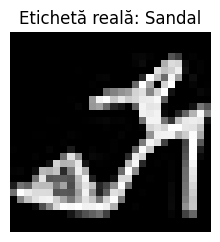

In [3]:
# Fashion-MNIST: 60 000 imagini 28x28, 10 clase de articole vestimentare
(X_train, y_train), (_, _) = tf.keras.datasets.fashion_mnist.load_data()
print("Forma:", X_train.shape, "| dtype:", X_train.dtype,
      "| Min/Max:", X_train.min(), X_train.max())

CLASSES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Afișăm o imagine reală aleatoare pentru a verifica încărcarea
i = np.random.randint(0, X_train.shape[0])
plt.figure(figsize=(2.6, 2.6))
plt.imshow(X_train[i], cmap="gray")
plt.title(f"Etichetă reală: {CLASSES[y_train[i]]}")
plt.axis("off")
plt.show()

In [4]:
# (60000, 28, 28) -> (60000, 28, 28, 1) și float32
X_train = X_train.reshape(-1, 28, 28, 1).astype("float32")

# Normalizare din [0, 255] în [-1, 1] (compatibil cu activarea tanh din generator)
X_train = (X_train - 127.5) / 127.5
print("După preprocesare:", X_train.shape,
      "| Min/Max:", X_train[0].min(), X_train[0].max())

# Pipeline tf.data cu shuffle + batch
BUFFER_SIZE = 60000
BATCH_SIZE  = 256

train_ds = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .prefetch(tf.data.AUTOTUNE)
)
print(train_ds)

După preprocesare: (60000, 28, 28, 1) | Min/Max: -1.0 1.0
<_PrefetchDataset element_spec=TensorSpec(shape=(256, 28, 28, 1), dtype=tf.float32, name=None)>


## 3. Crearea modelului generator

Generatorul transformă un vector de zgomot de dimensiune `NOISE_DIM = 100` într-o
imagine `28×28×1`. Folosim straturi `Conv2DTranspose` pentru **upsampling**
(creșterea rezoluției) și `BatchNormalization` + `LeakyReLU` pentru stabilitate.
Stratul final are activare `tanh`, astfel încât ieșirile sunt în intervalul
`[-1, 1]`, exact ca datele preprocesate.


In [5]:
NOISE_DIM = 100

def build_generator():
    model = Sequential(name="generator")

    # Pornim de la zgomot 100-dim și îl proiectăm într-un volum 7x7x256
    model.add(Dense(7 * 7 * 256, use_bias=False, input_shape=(NOISE_DIM,)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Reshape((7, 7, 256)))

    # 7x7x256 -> 7x7x128 (păstrăm rezoluția, reducem numărul de filtre)
    model.add(Conv2DTranspose(128, kernel_size=5, strides=1,
                              padding="same", use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.2))

    # 7x7x128 -> 14x14x64 (strides=2 dublează rezoluția spațială)
    model.add(Conv2DTranspose(64, kernel_size=5, strides=2,
                              padding="same", use_bias=False))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.2))

    # 14x14x64 -> 28x28x1 (stratul de ieșire, tanh -> [-1, 1])
    model.add(Conv2DTranspose(1, kernel_size=5, strides=2,
                              padding="same", use_bias=False, activation="tanh"))
    return model

generator = build_generator()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

Forma imaginii generate: (1, 28, 28, 1)


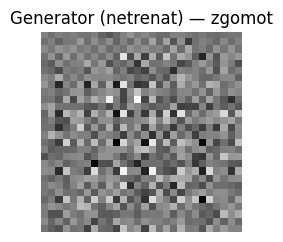

In [6]:
# Verificare „țevărie": generatorul netrenat produce doar zgomot
noise = tf.random.normal([1, NOISE_DIM])
fake_img = generator(noise, training=False)
print("Forma imaginii generate:", fake_img.shape)

plt.figure(figsize=(2.6, 2.6))
plt.imshow(fake_img[0, :, :, 0], cmap="gray")
plt.title("Generator (netrenat) — zgomot")
plt.axis("off")
plt.show()

## 4. Crearea modelului discriminator

Discriminatorul este o **rețea convoluțională pentru clasificare binară**:
primește o imagine `28×28×1` și returnează un **logit** (un scalar, fără
sigmoid). Sigmoidul este aplicat implicit de funcția de pierdere prin
`from_logits=True` (mai stabil numeric). Folosim `Conv2D` cu `strides=2`
pentru **downsampling** și `Dropout` pentru regularizare.


In [7]:
def build_discriminator():
    model = Sequential(name="discriminator")

    # 28x28x1 -> 14x14x64
    model.add(Conv2D(64, kernel_size=5, strides=2, padding="same",
                     input_shape=(28, 28, 1)))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.3))

    # 14x14x64 -> 7x7x128
    model.add(Conv2D(128, kernel_size=5, strides=2, padding="same"))
    model.add(LeakyReLU(negative_slope=0.2))
    model.add(Dropout(0.3))

    # Cap dens: logit pentru clasificare binară (real vs. fals)
    model.add(Flatten())
    model.add(Dense(1))
    return model

discriminator = build_discriminator()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Pentru o rețea netrenată, logitul ar trebui să fie aproape de 0
# -> sigmoid(~0) ≈ 0.5 (incertitudine maximă)
logit = discriminator(fake_img, training=False)
print("Logit:", float(logit[0, 0]),
      "| Probabilitate (sigmoid):", float(tf.sigmoid(logit)[0, 0]))

Logit: 0.0014522896381095052 | Probabilitate (sigmoid): 0.5003630518913269


## 5. Funcțiile de pierdere și optimizatorii

Folosim `BinaryCrossentropy(from_logits=True)`. Convențiile:

- **Pierderea discriminatorului** = pierderea pe imagini reale (etichetă **1**) +
  pierderea pe imagini false (etichetă **0**). Discriminatorul vrea să le
  distingă.
- **Pierderea generatorului** = pierderea calculată ca și cum imaginile false ar
  trebui să fie clasificate ca **1** (reale). Generatorul „înșeală"
  discriminatorul.

Pentru optimizator folosim **Adam** cu rată de învățare `1e-4`, o valoare
standard pentru DCGAN, care echilibrează generatorul și discriminatorul.


In [9]:
cross_entropy = BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_logits, fake_logits):
    # Imaginile reale -> etichetă 1; imaginile false -> etichetă 0
    real_loss = cross_entropy(tf.ones_like(real_logits),  real_logits)
    fake_loss = cross_entropy(tf.zeros_like(fake_logits), fake_logits)
    return real_loss + fake_loss

def generator_loss(fake_logits):
    # Generatorul „minte": vrea ca discriminatorul să le clasifice ca 1 (reale)
    return cross_entropy(tf.ones_like(fake_logits), fake_logits)

generator_optimizer     = Adam(learning_rate=1e-4)
discriminator_optimizer = Adam(learning_rate=1e-4)

## 6. Antrenarea modelului GAN

Bucla de antrenare definește, într-un singur `train_step`:

1. Se eșantionează un batch de zgomot și se generează imagini false.
2. Discriminatorul evaluează **separat** imaginile reale și pe cele false.
3. Se calculează pierderile pentru generator și discriminator.
4. Se aplică gradient descent pe ambele rețele **independent**.



Epoca   1/100 | g_loss=0.7283 | d_loss=1.1831 | 18.6s


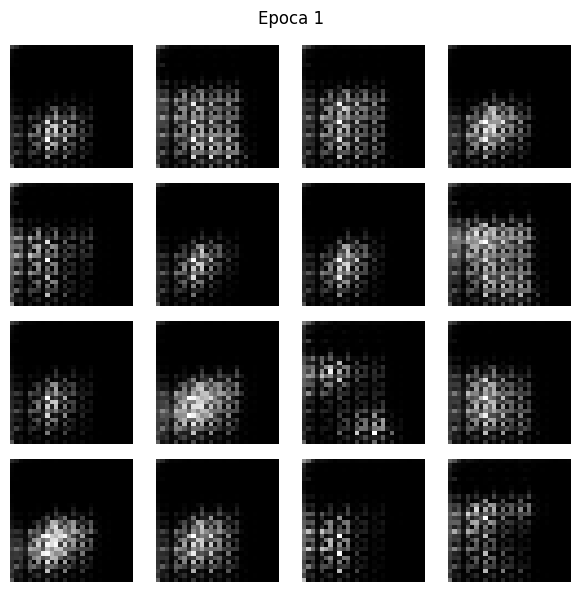

Epoca   2/100 | g_loss=0.9019 | d_loss=1.1602 | 12.7s


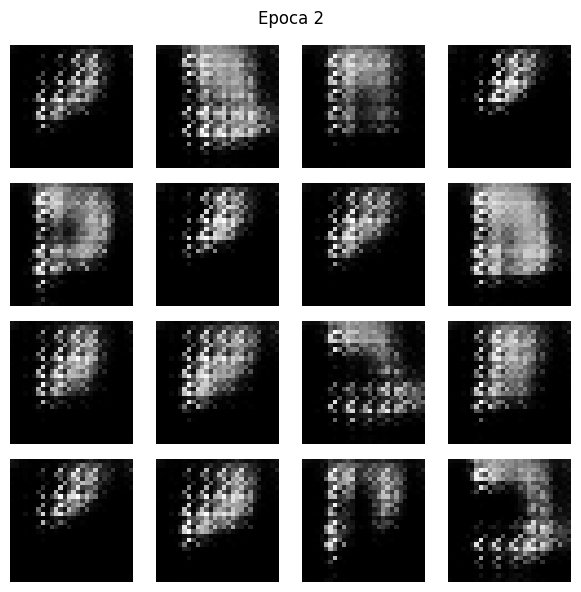

Epoca   3/100 | g_loss=0.9400 | d_loss=1.2175 | 12.8s


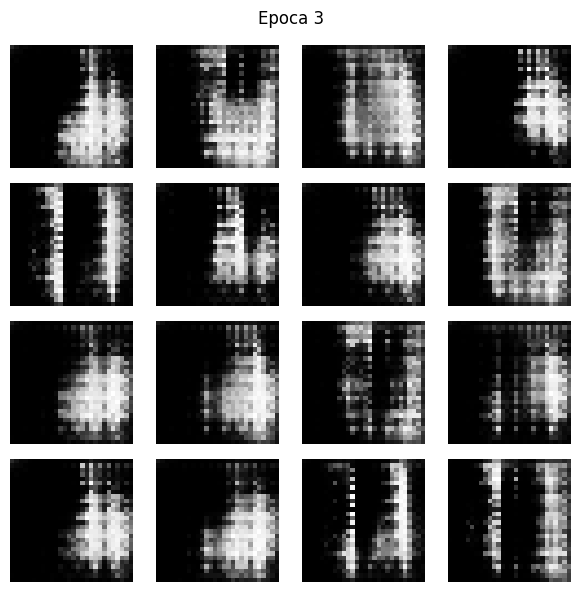

Epoca   4/100 | g_loss=0.9777 | d_loss=1.1742 | 13.1s


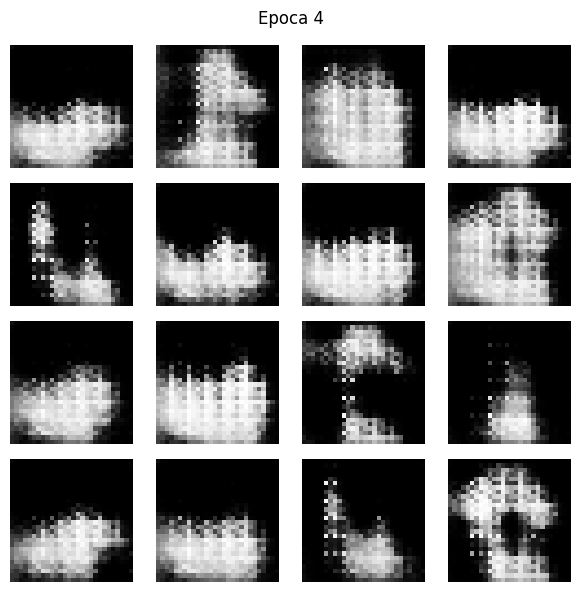

Epoca   5/100 | g_loss=0.9949 | d_loss=1.1117 | 13.4s


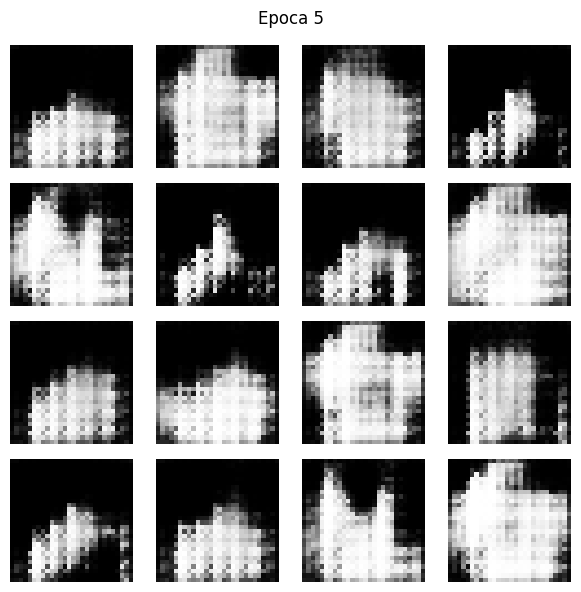

Epoca   6/100 | g_loss=0.9262 | d_loss=1.2245 | 13.8s


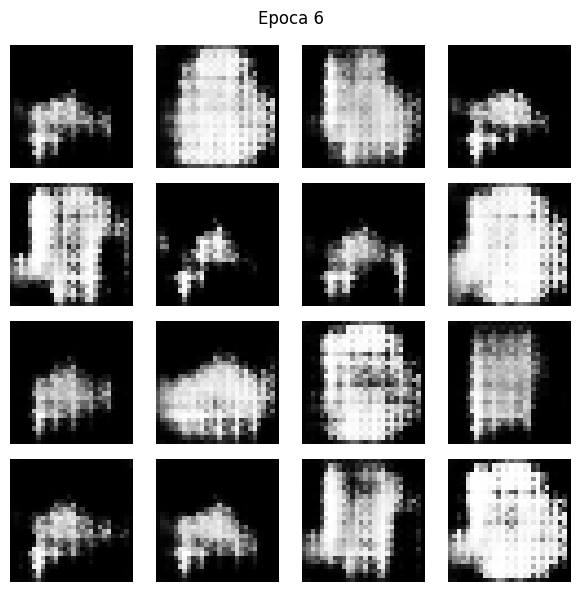

Epoca   7/100 | g_loss=0.8883 | d_loss=1.2309 | 14.3s


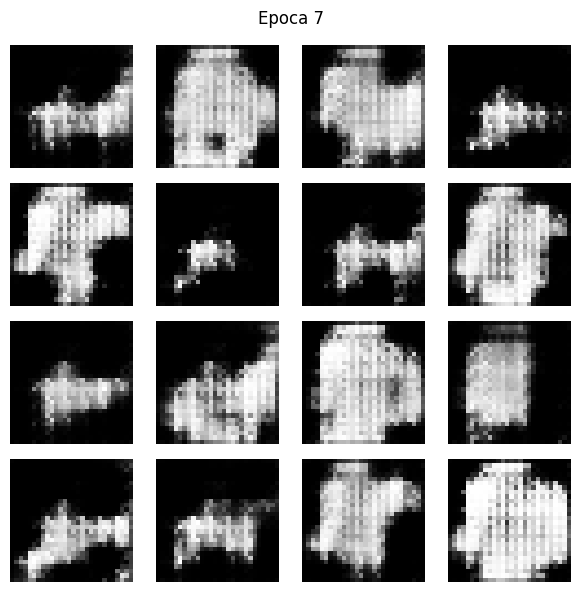

Epoca   8/100 | g_loss=0.8791 | d_loss=1.2423 | 14.3s


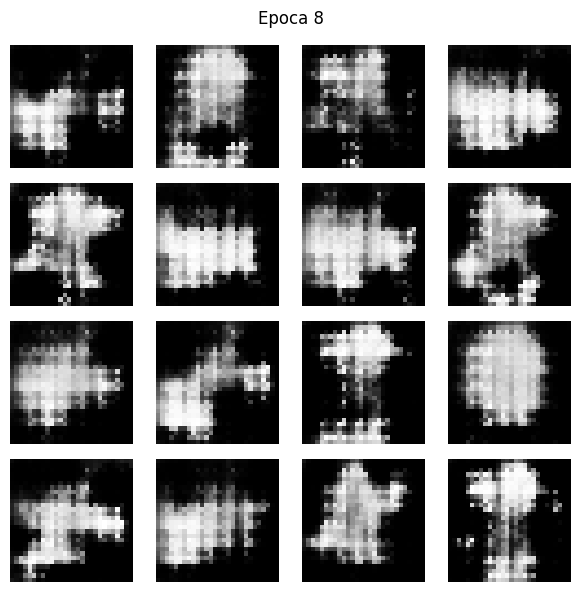

Epoca   9/100 | g_loss=1.0012 | d_loss=1.1286 | 14.3s


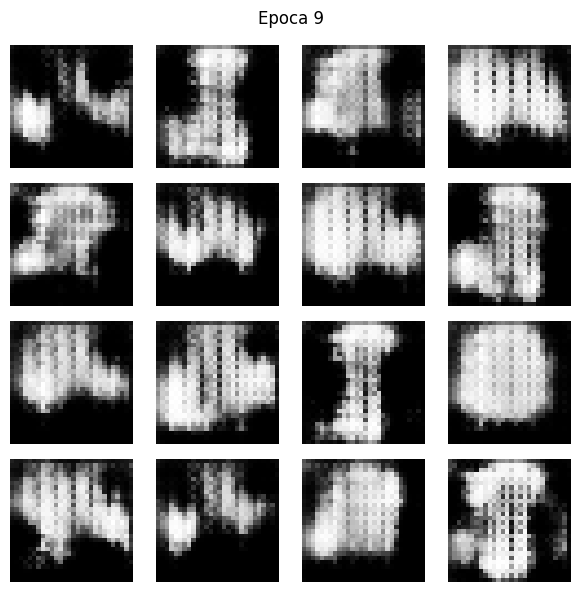

Epoca  10/100 | g_loss=1.0074 | d_loss=1.1443 | 14.3s


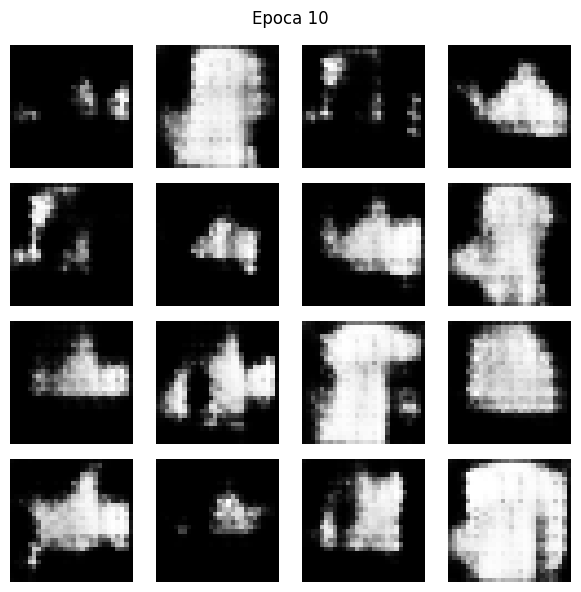

Epoca  11/100 | g_loss=1.0414 | d_loss=1.0997 | 14.3s


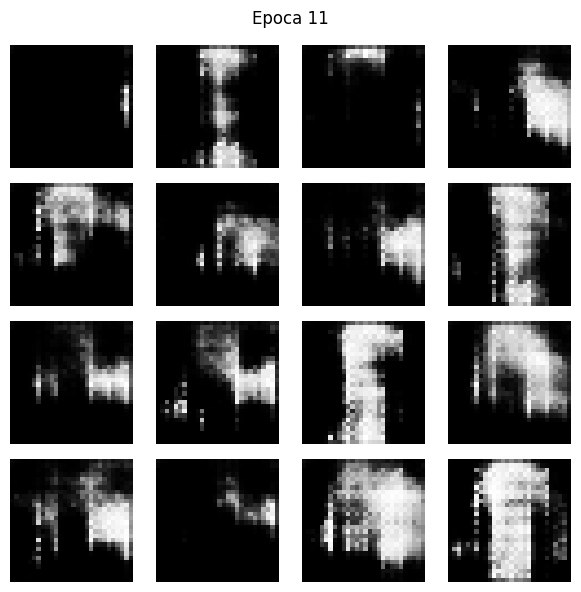

Epoca  12/100 | g_loss=1.1364 | d_loss=1.0034 | 14.3s


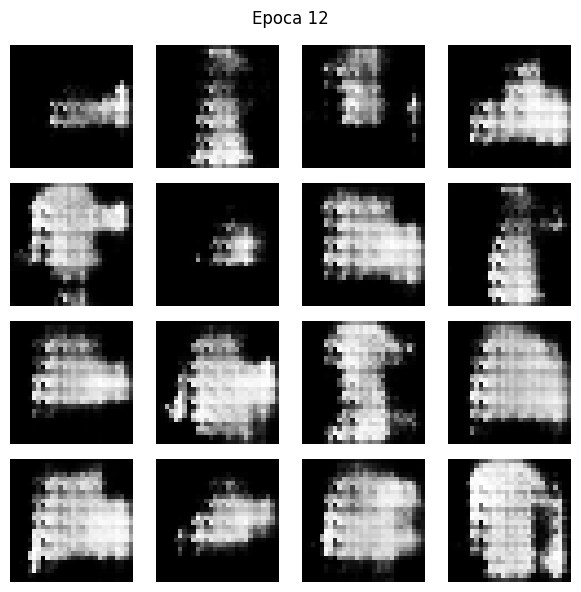

Epoca  13/100 | g_loss=1.2000 | d_loss=0.9548 | 14.3s


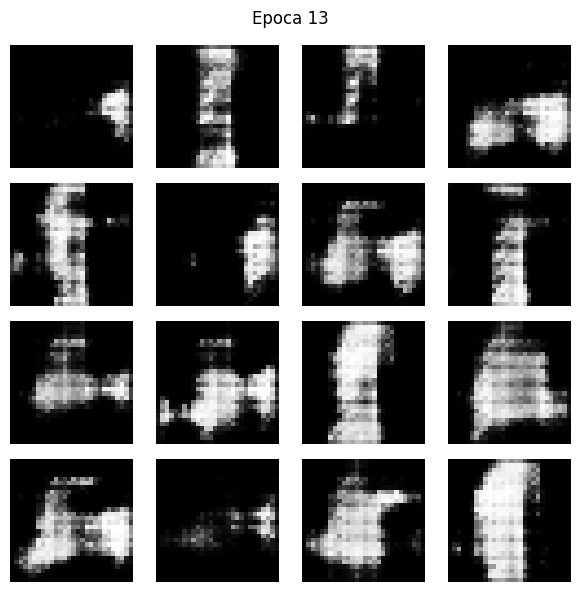

Epoca  14/100 | g_loss=1.1790 | d_loss=1.0086 | 14.3s


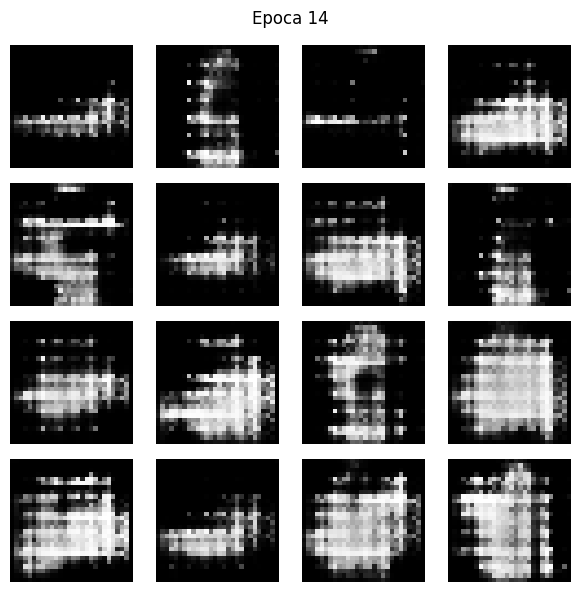

Epoca  15/100 | g_loss=1.3206 | d_loss=0.9164 | 14.3s


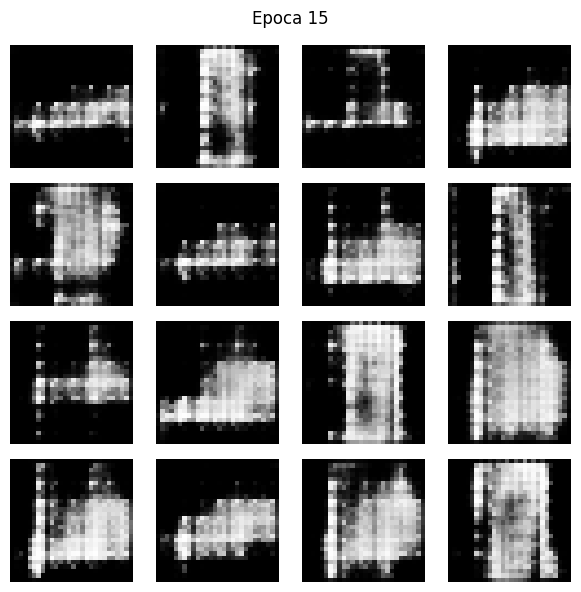

Epoca  16/100 | g_loss=1.3491 | d_loss=0.8488 | 14.3s


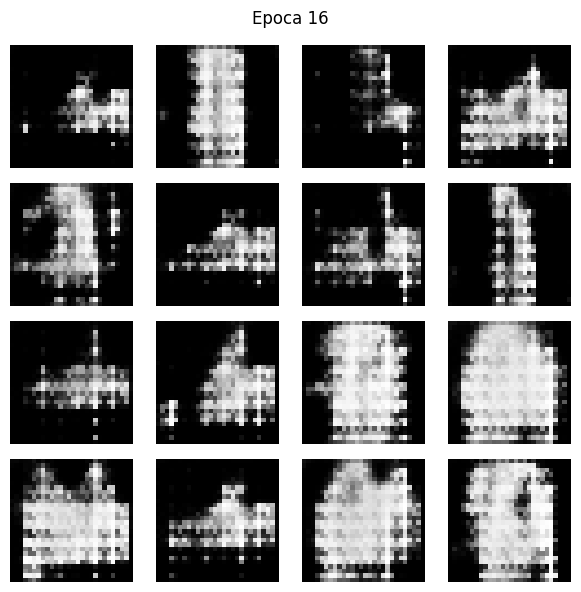

Epoca  17/100 | g_loss=1.6024 | d_loss=0.7762 | 14.3s


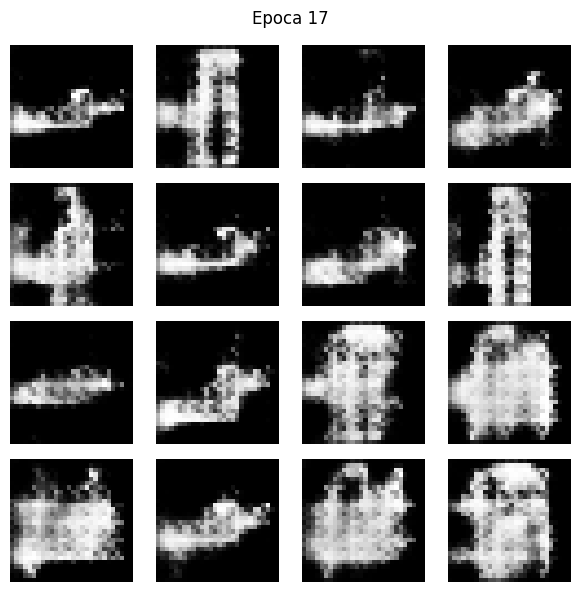

Epoca  18/100 | g_loss=1.6569 | d_loss=0.7323 | 14.3s


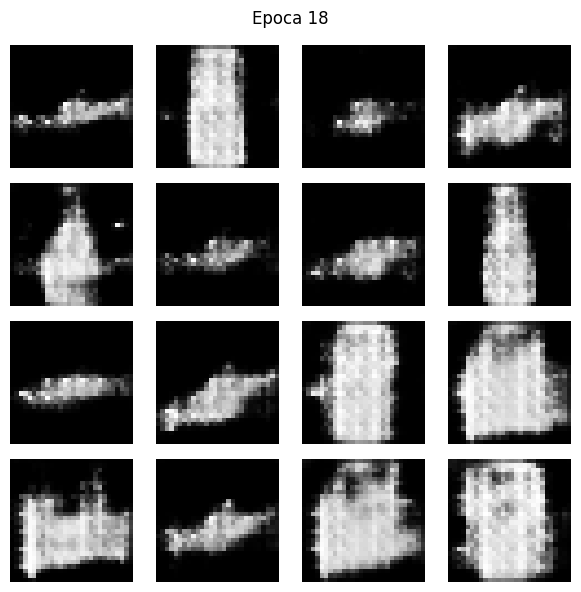

Epoca  19/100 | g_loss=1.6609 | d_loss=0.7057 | 14.3s


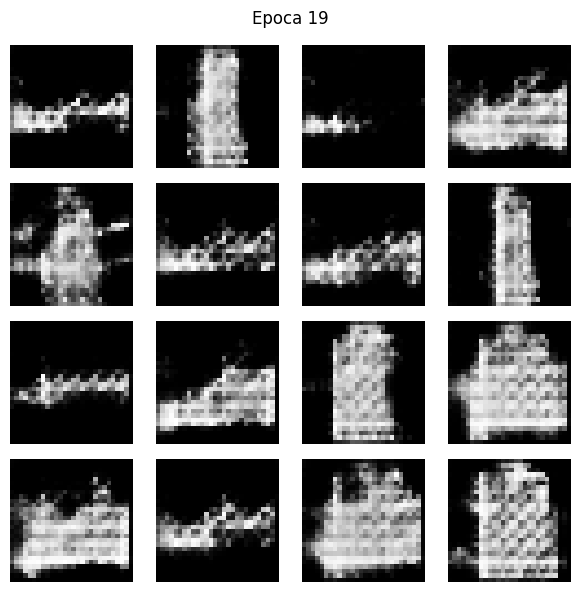

Epoca  20/100 | g_loss=1.7095 | d_loss=0.7434 | 14.3s


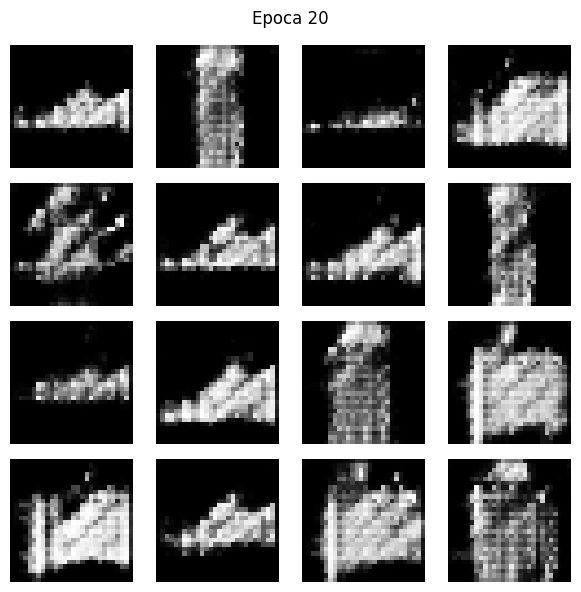

Epoca  21/100 | g_loss=1.6827 | d_loss=0.7534 | 14.3s


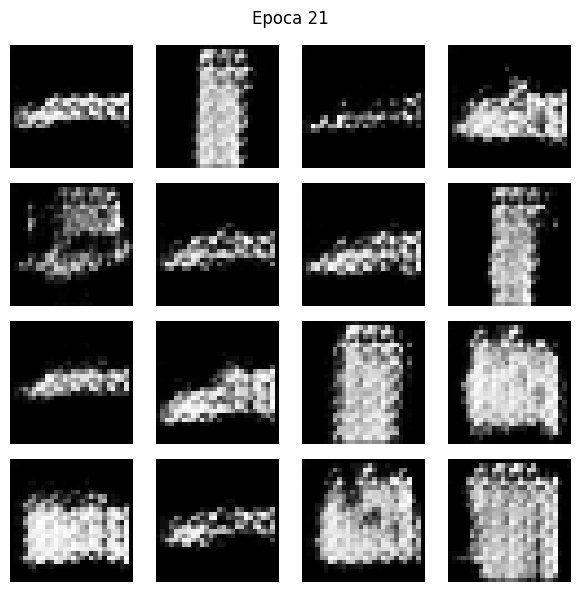

Epoca  22/100 | g_loss=1.6373 | d_loss=0.7375 | 14.3s


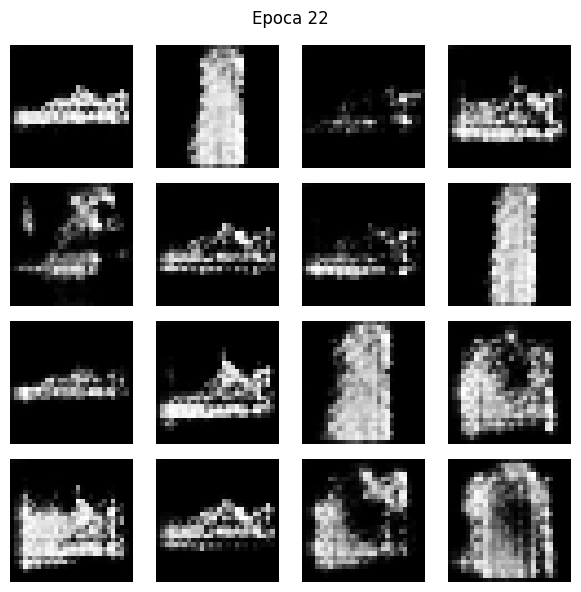

Epoca  23/100 | g_loss=1.7904 | d_loss=0.7690 | 14.3s


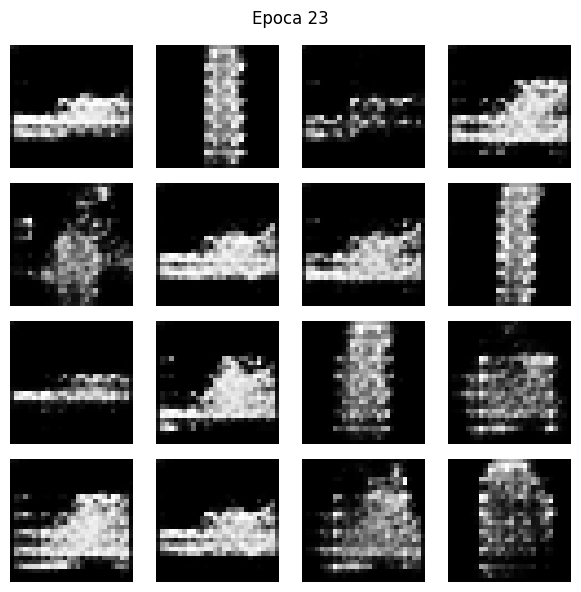

Epoca  24/100 | g_loss=1.7376 | d_loss=0.7140 | 14.3s


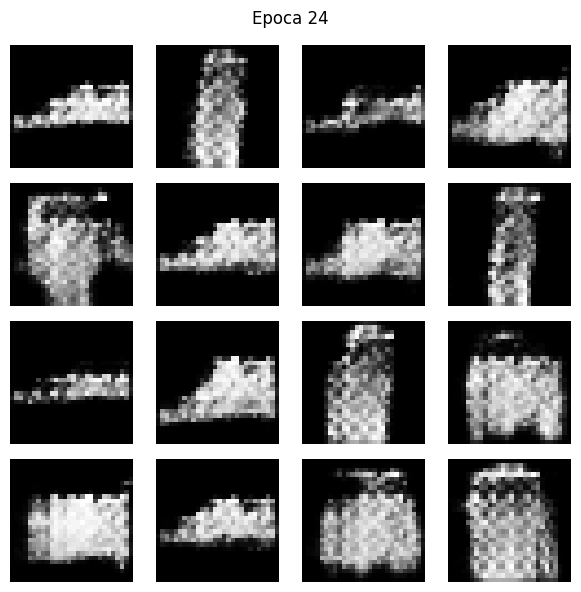

Epoca  25/100 | g_loss=1.6925 | d_loss=0.7650 | 14.3s


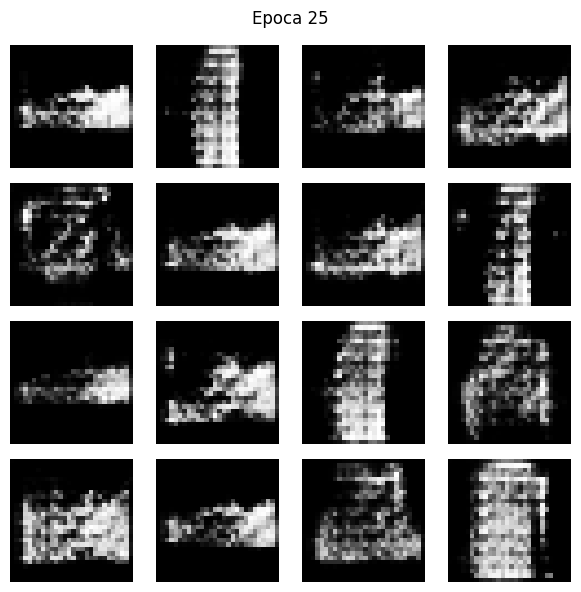

Epoca  26/100 | g_loss=1.6466 | d_loss=0.7786 | 14.3s


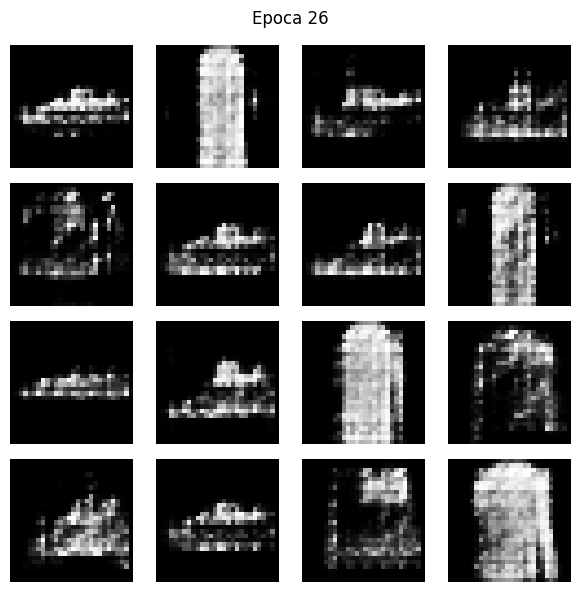

Epoca  27/100 | g_loss=1.6952 | d_loss=0.7812 | 14.3s


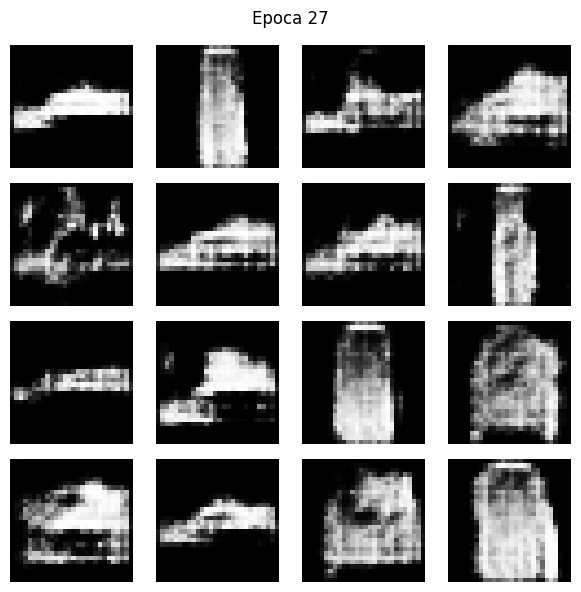

Epoca  28/100 | g_loss=1.6318 | d_loss=0.8289 | 14.3s


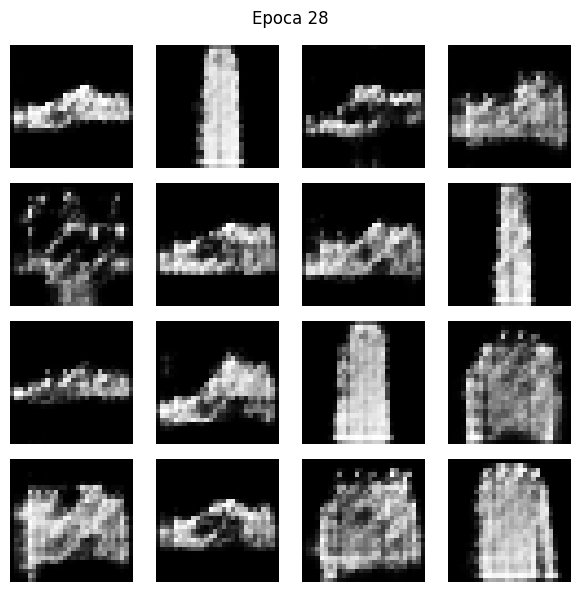

Epoca  29/100 | g_loss=1.6145 | d_loss=0.7753 | 14.3s


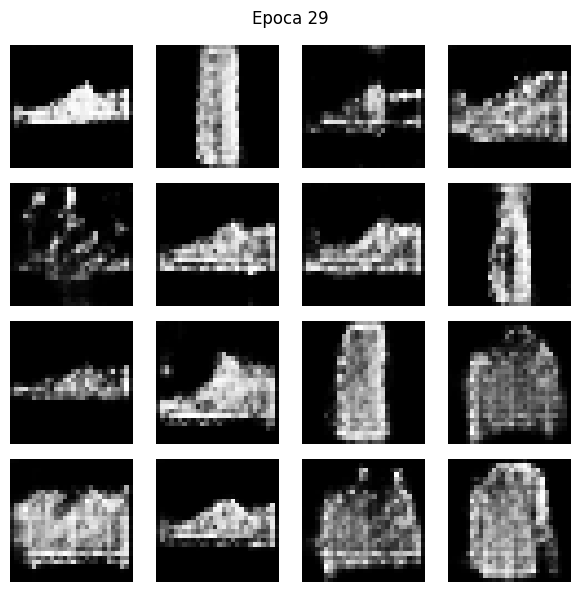

Epoca  30/100 | g_loss=1.5459 | d_loss=0.8416 | 14.3s


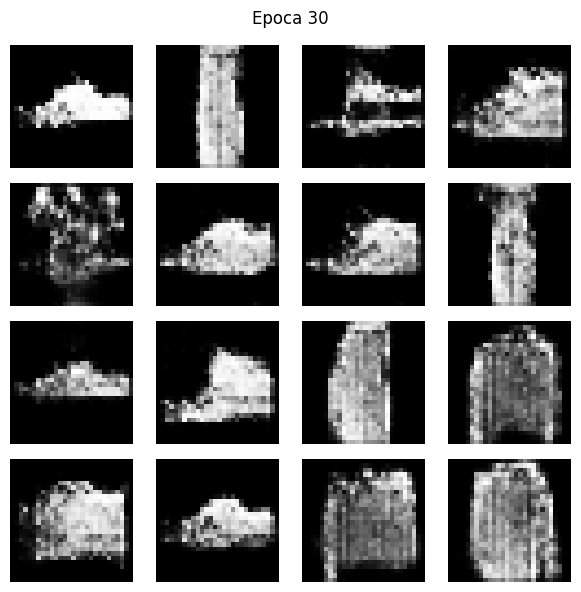

Epoca  31/100 | g_loss=1.5770 | d_loss=0.8406 | 14.3s


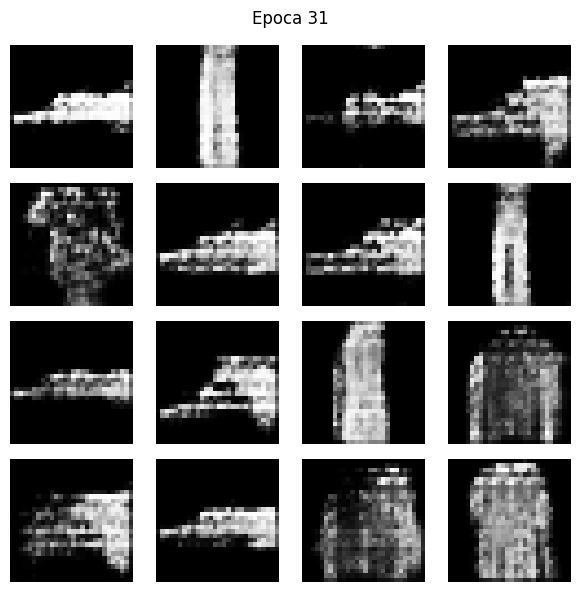

Epoca  32/100 | g_loss=1.5201 | d_loss=0.8477 | 14.3s


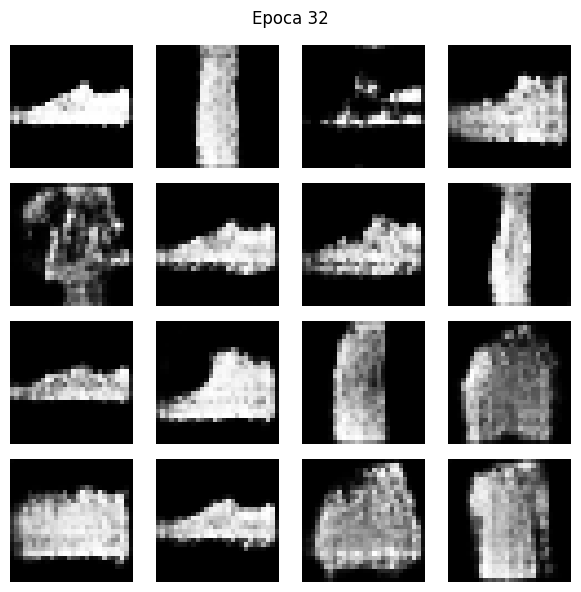

Epoca  33/100 | g_loss=1.4770 | d_loss=0.8464 | 14.3s


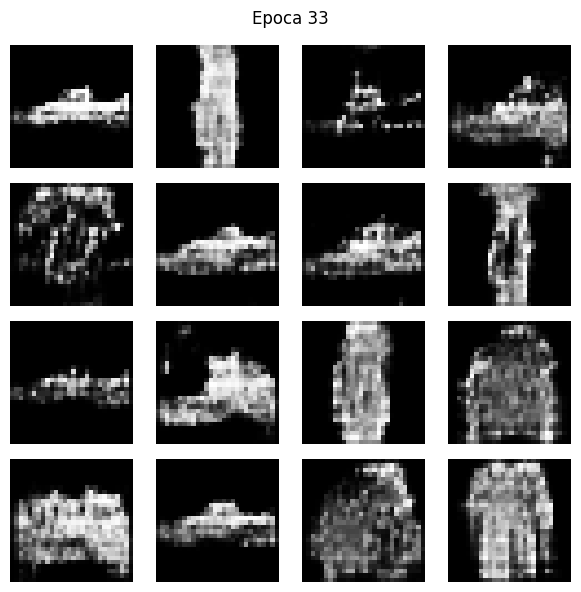

Epoca  34/100 | g_loss=1.4545 | d_loss=0.8730 | 14.3s


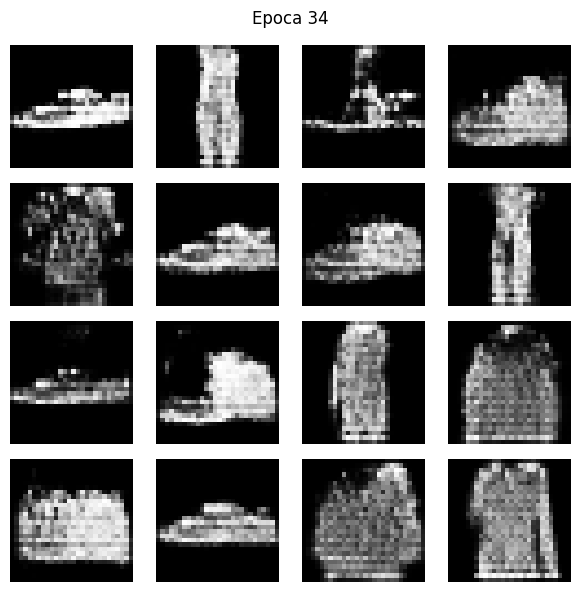

Epoca  35/100 | g_loss=1.4447 | d_loss=0.9018 | 14.3s


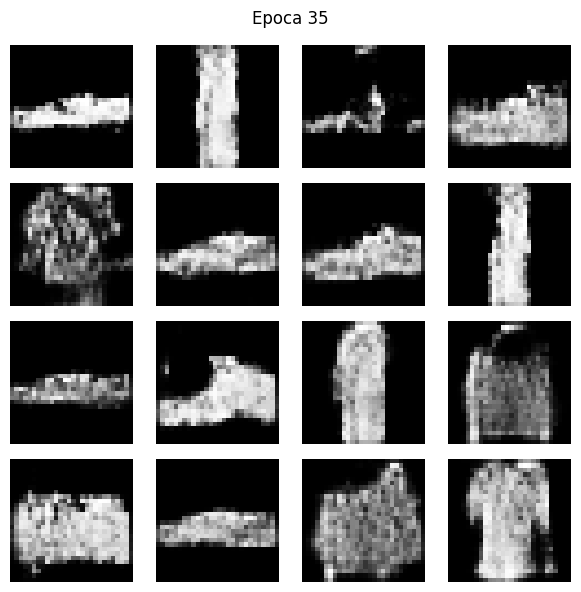

Epoca  36/100 | g_loss=1.4768 | d_loss=0.8870 | 14.3s


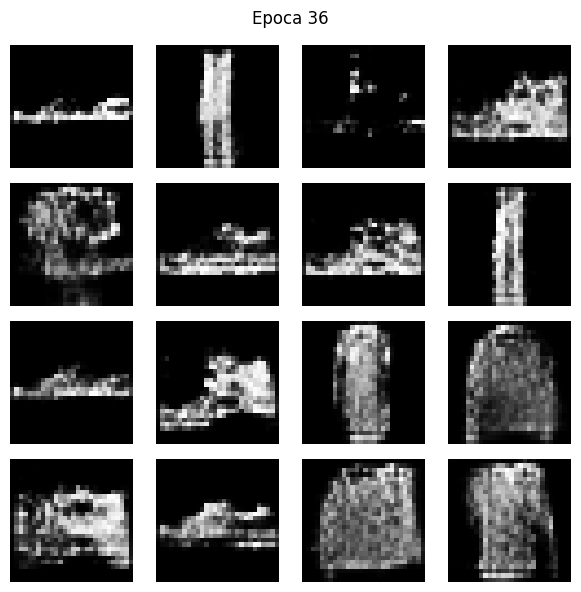

Epoca  37/100 | g_loss=1.4176 | d_loss=0.9137 | 14.3s


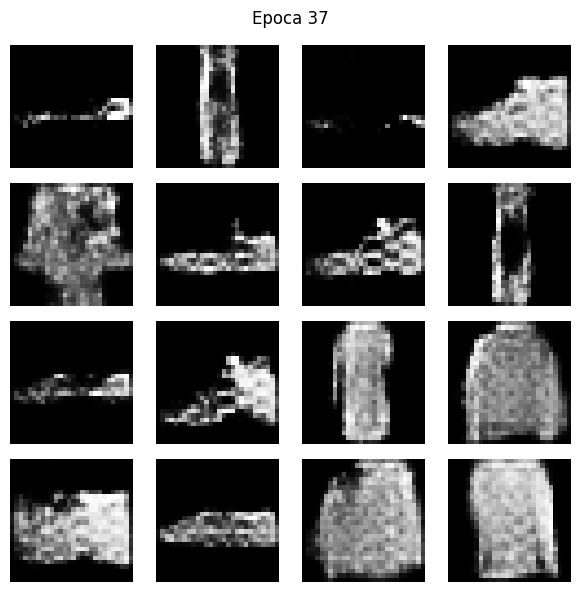

Epoca  38/100 | g_loss=1.4575 | d_loss=0.8694 | 14.3s


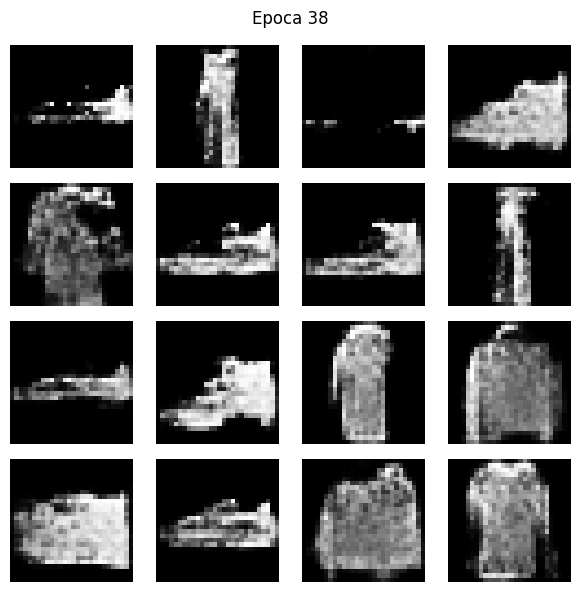

Epoca  39/100 | g_loss=1.4950 | d_loss=0.8954 | 14.3s


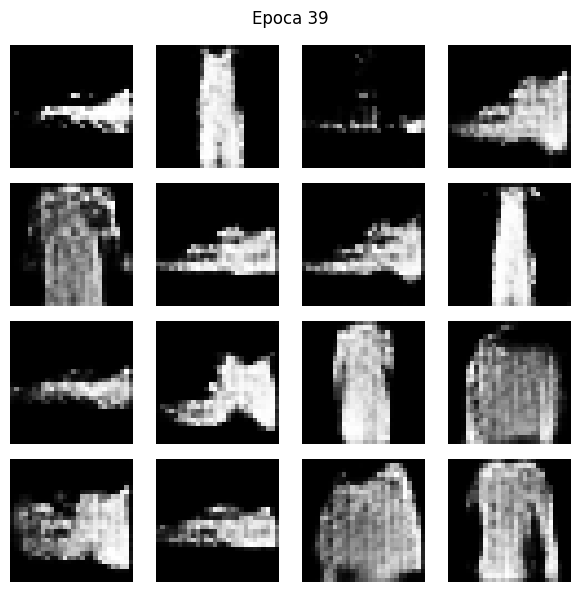

Epoca  40/100 | g_loss=1.4235 | d_loss=0.9364 | 14.3s


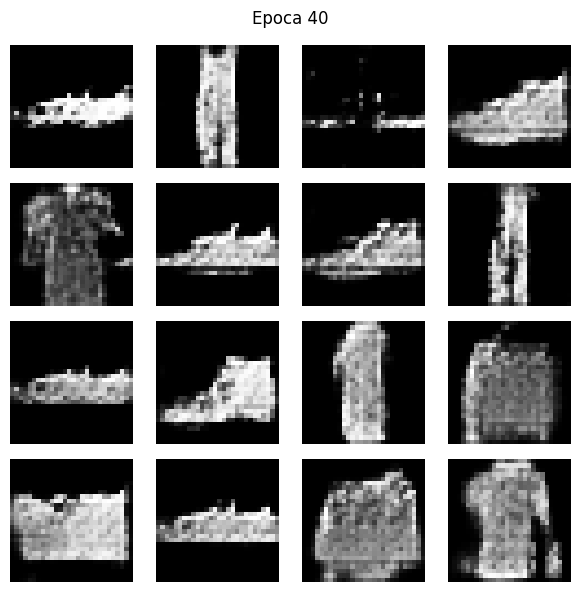

Epoca  41/100 | g_loss=1.4620 | d_loss=0.9239 | 14.3s


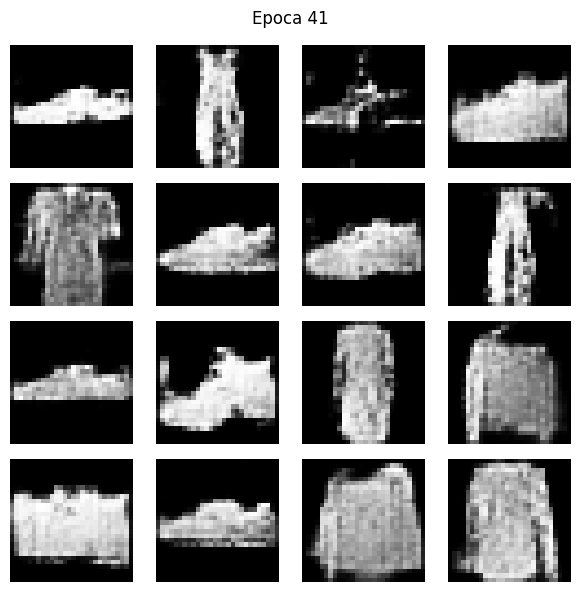

Epoca  42/100 | g_loss=1.3724 | d_loss=0.9510 | 14.3s


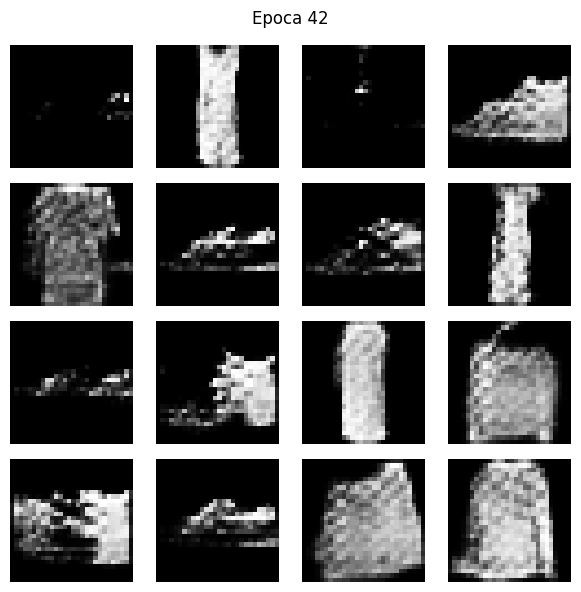

Epoca  43/100 | g_loss=1.4080 | d_loss=0.9389 | 14.3s


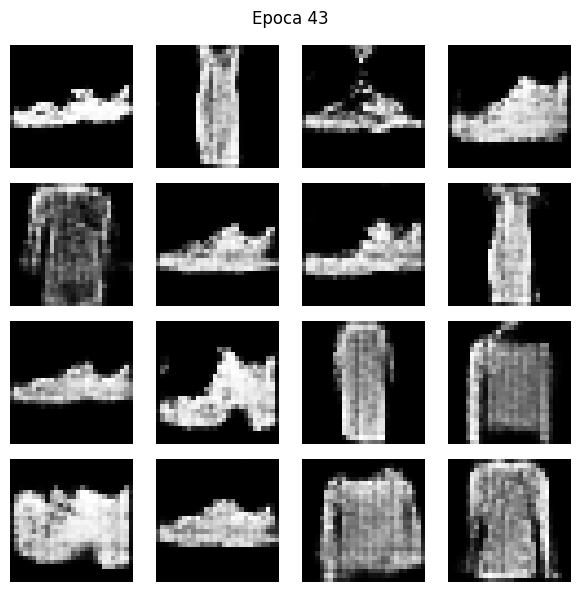

Epoca  44/100 | g_loss=1.4617 | d_loss=0.9097 | 14.3s


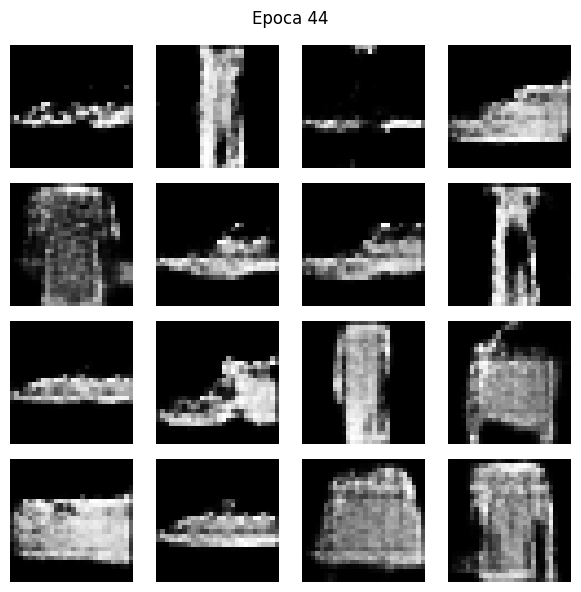

Epoca  45/100 | g_loss=1.4872 | d_loss=0.9134 | 14.3s


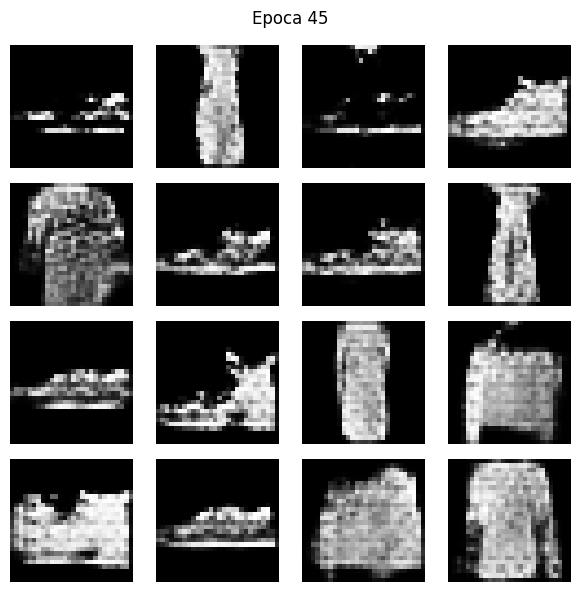

Epoca  46/100 | g_loss=1.3350 | d_loss=0.9693 | 14.3s


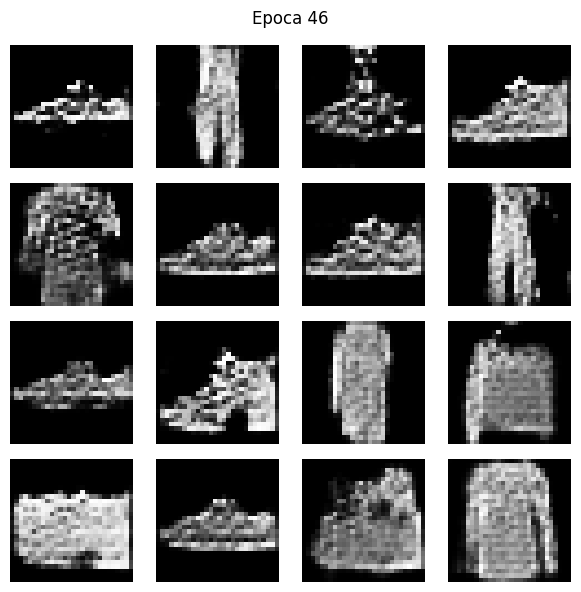

Epoca  47/100 | g_loss=1.3271 | d_loss=0.9618 | 14.3s


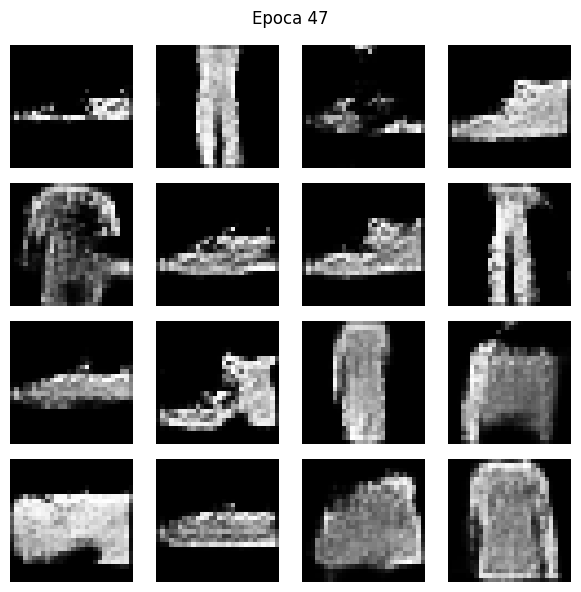

Epoca  48/100 | g_loss=1.2883 | d_loss=0.9952 | 14.3s


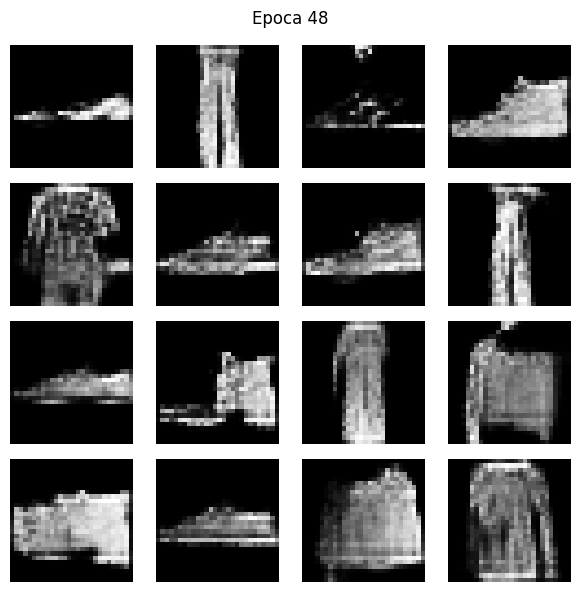

Epoca  49/100 | g_loss=1.3337 | d_loss=0.9846 | 14.3s


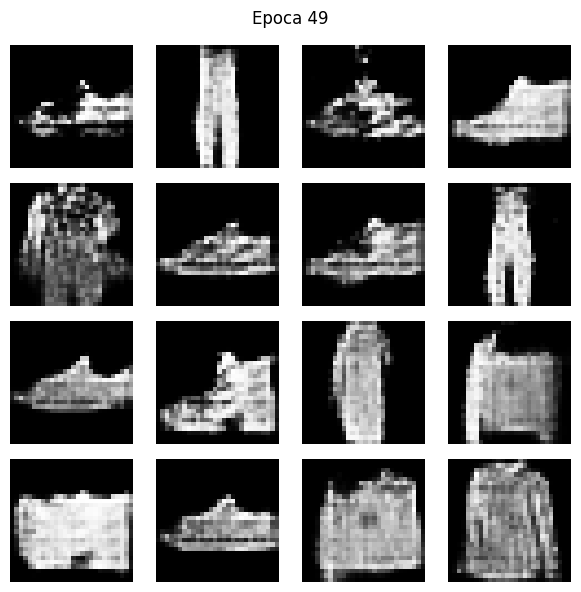

Epoca  50/100 | g_loss=1.2909 | d_loss=0.9872 | 14.4s


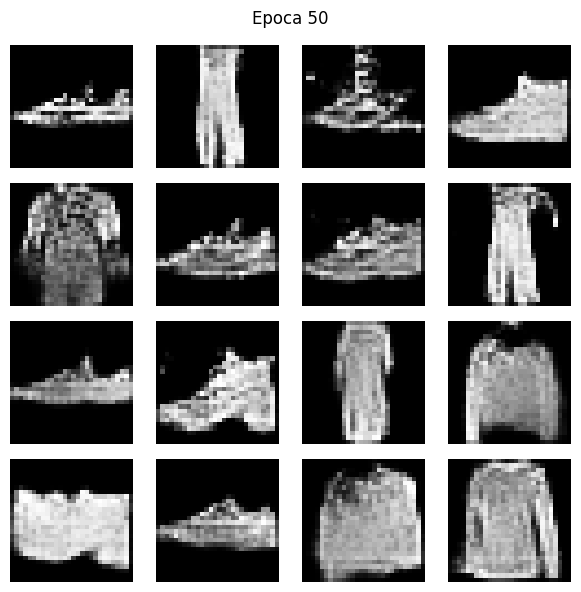

Epoca  51/100 | g_loss=1.2653 | d_loss=1.0092 | 14.3s


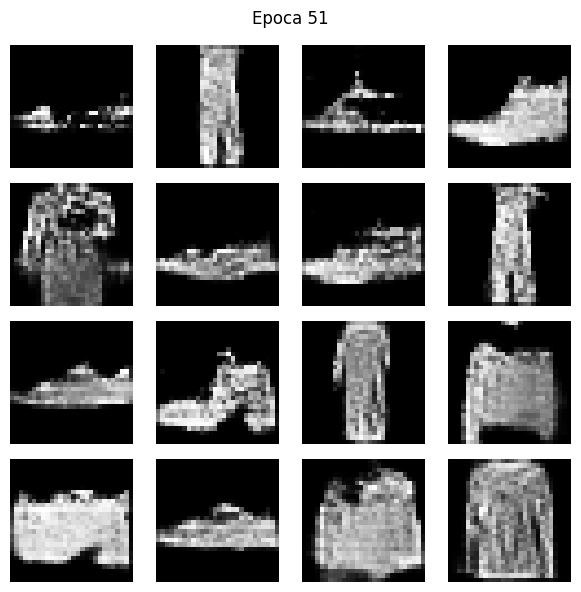

Epoca  52/100 | g_loss=1.2507 | d_loss=1.0252 | 14.3s


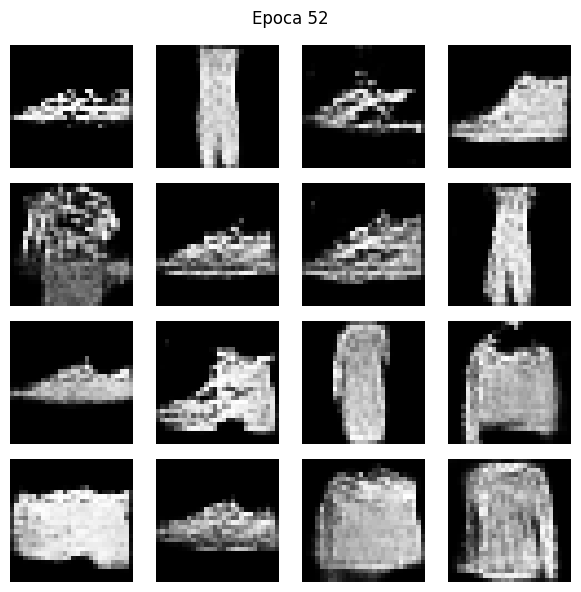

Epoca  53/100 | g_loss=1.2762 | d_loss=1.0163 | 14.3s


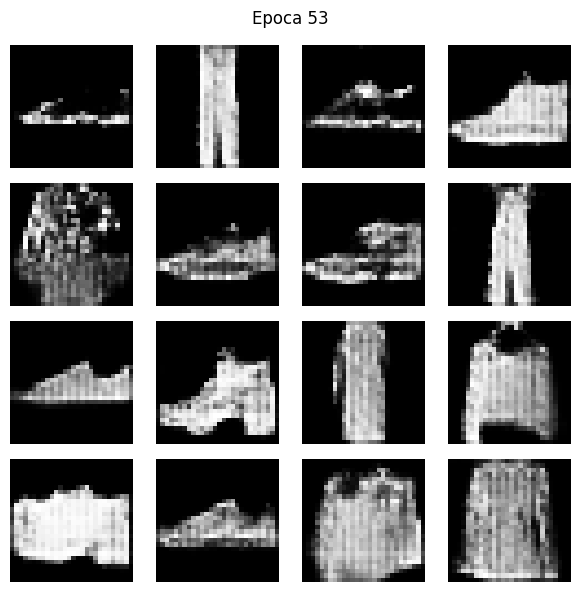

Epoca  54/100 | g_loss=1.2737 | d_loss=1.0173 | 14.3s


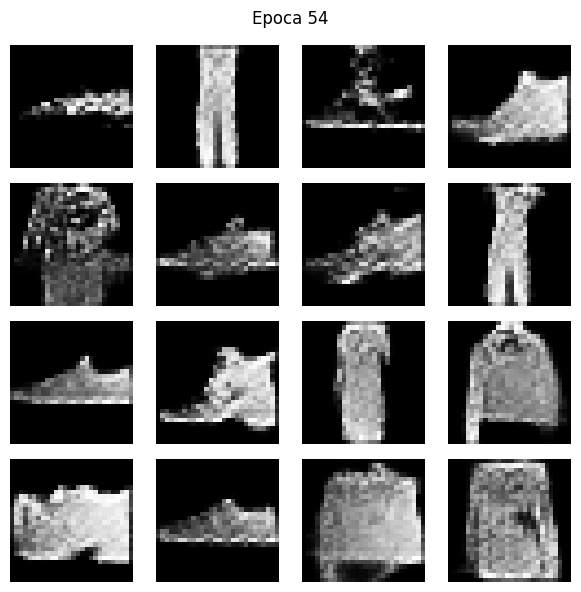

Epoca  55/100 | g_loss=1.2168 | d_loss=1.0472 | 14.3s


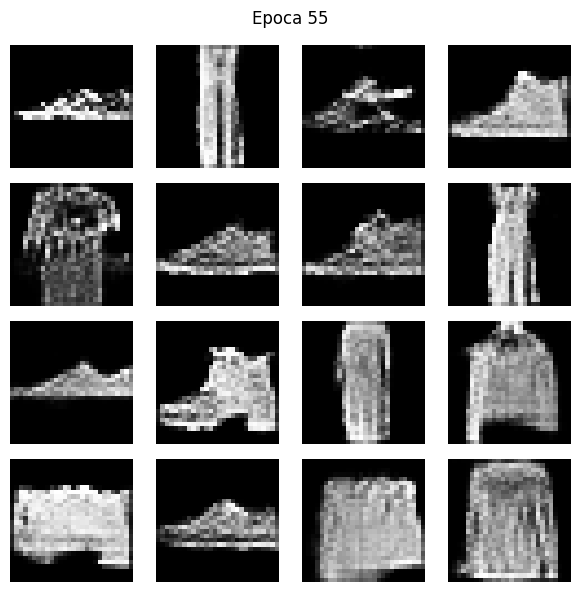

Epoca  56/100 | g_loss=1.2408 | d_loss=1.0534 | 14.3s


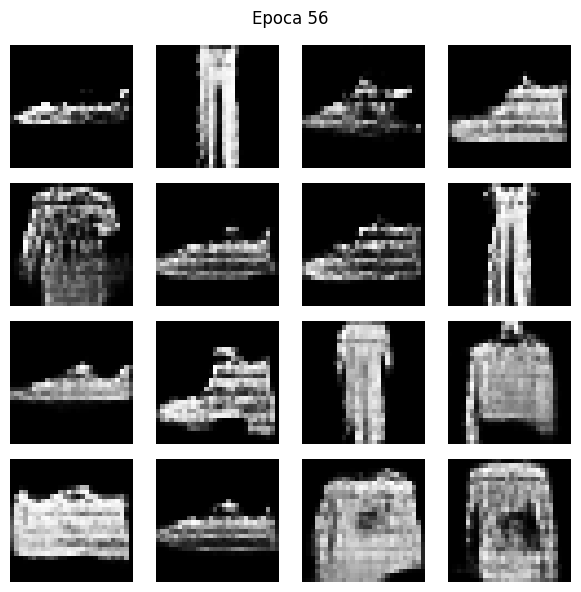

Epoca  57/100 | g_loss=1.2785 | d_loss=1.0245 | 14.3s


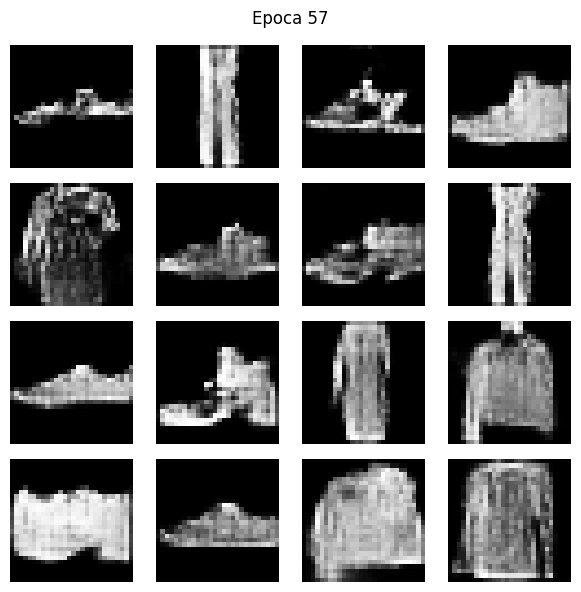

Epoca  58/100 | g_loss=1.2401 | d_loss=1.0551 | 14.3s


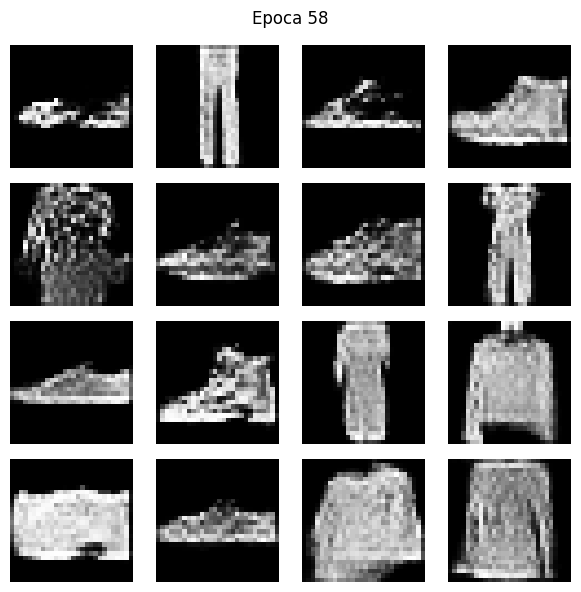

Epoca  59/100 | g_loss=1.2105 | d_loss=1.0425 | 14.3s


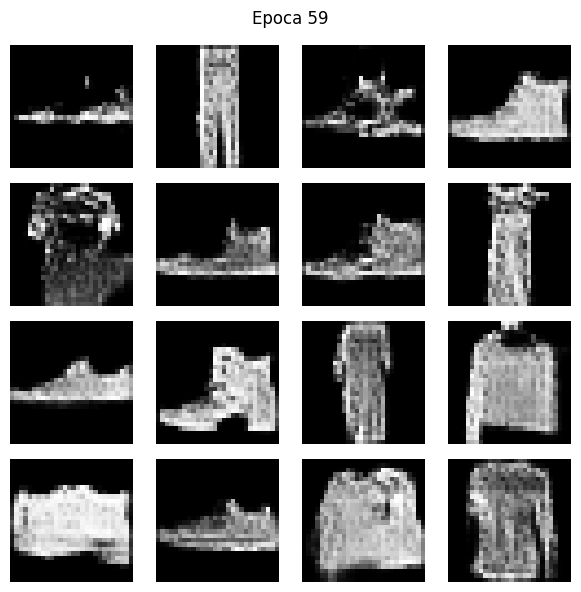

Epoca  60/100 | g_loss=1.1931 | d_loss=1.0783 | 14.3s


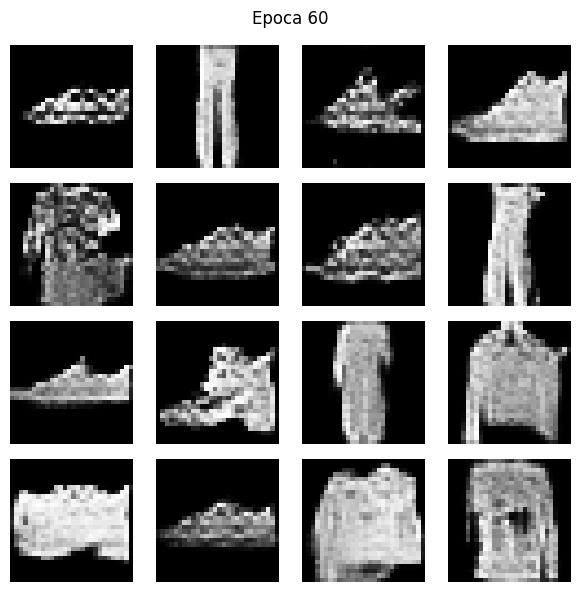

Epoca  61/100 | g_loss=1.1789 | d_loss=1.0712 | 14.3s


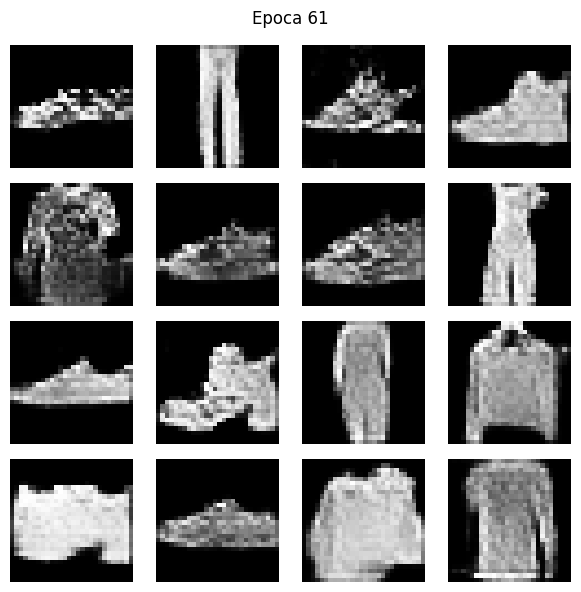

Epoca  62/100 | g_loss=1.2069 | d_loss=1.0735 | 14.3s


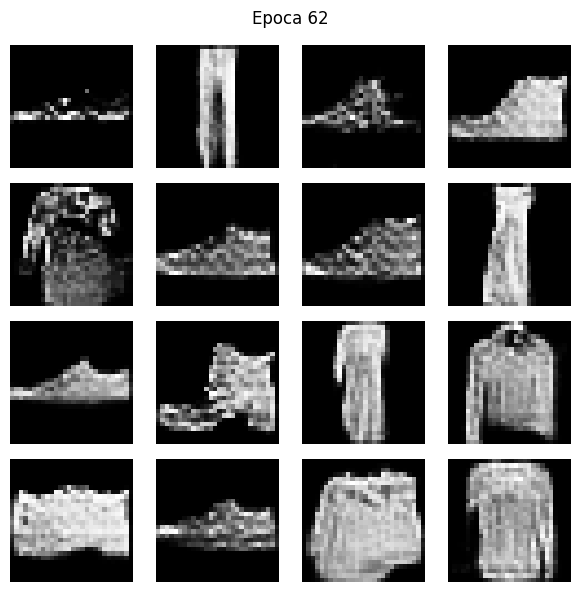

Epoca  63/100 | g_loss=1.1722 | d_loss=1.0922 | 14.3s


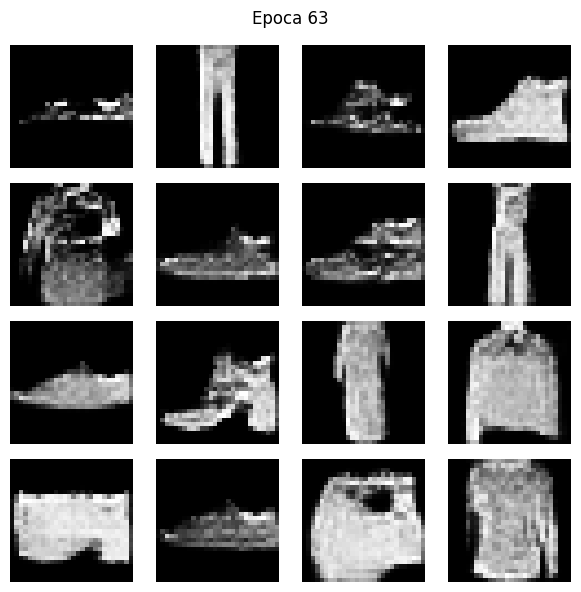

Epoca  64/100 | g_loss=1.2014 | d_loss=1.0577 | 14.3s


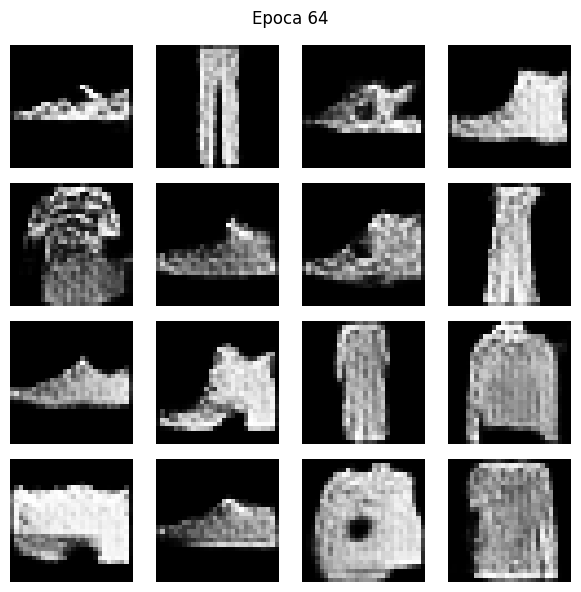

Epoca  65/100 | g_loss=1.1679 | d_loss=1.0874 | 14.3s


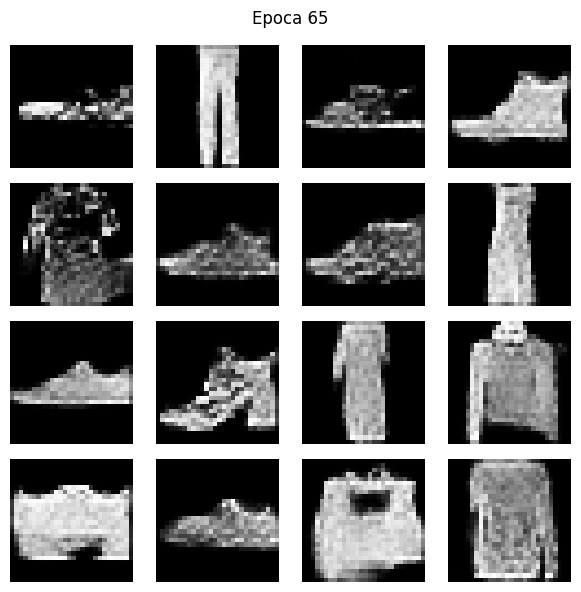

Epoca  66/100 | g_loss=1.1433 | d_loss=1.1030 | 14.3s


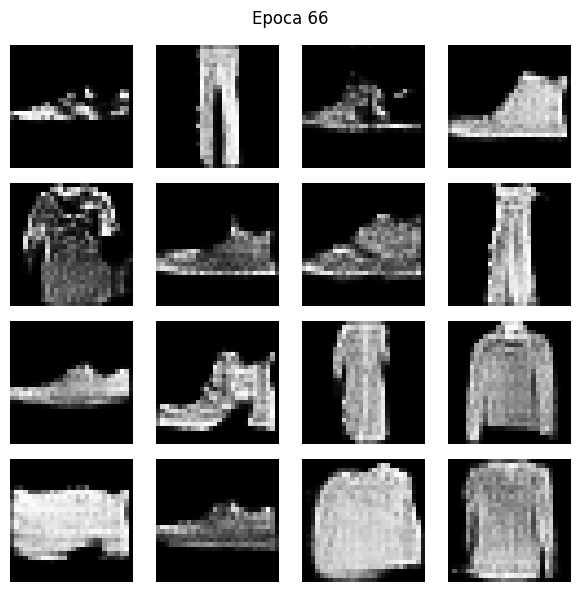

Epoca  67/100 | g_loss=1.1303 | d_loss=1.1242 | 14.3s


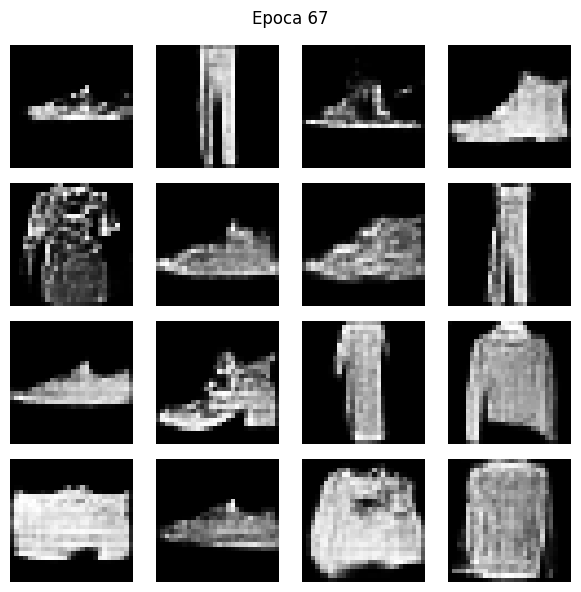

Epoca  68/100 | g_loss=1.1209 | d_loss=1.1089 | 14.3s


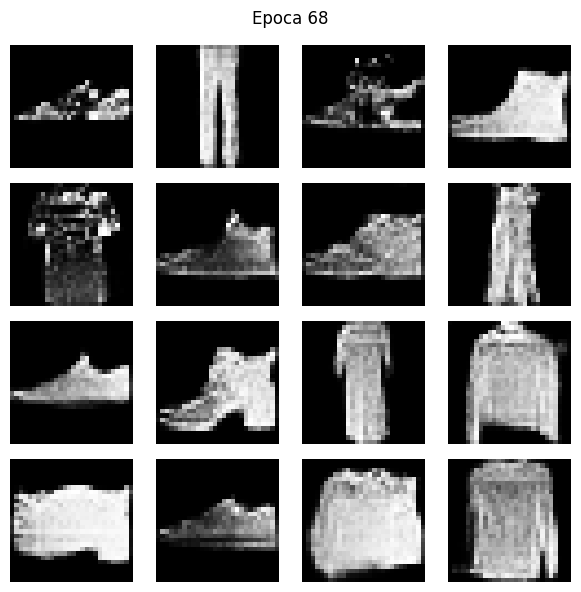

Epoca  69/100 | g_loss=1.1101 | d_loss=1.1209 | 14.3s


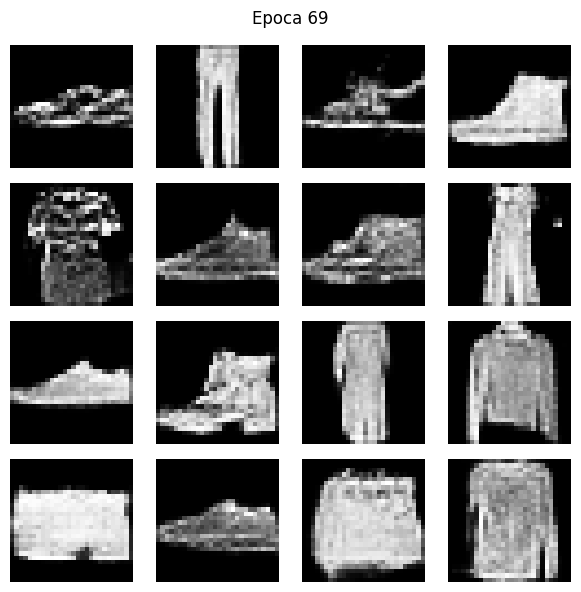

Epoca  70/100 | g_loss=1.1024 | d_loss=1.1323 | 14.3s


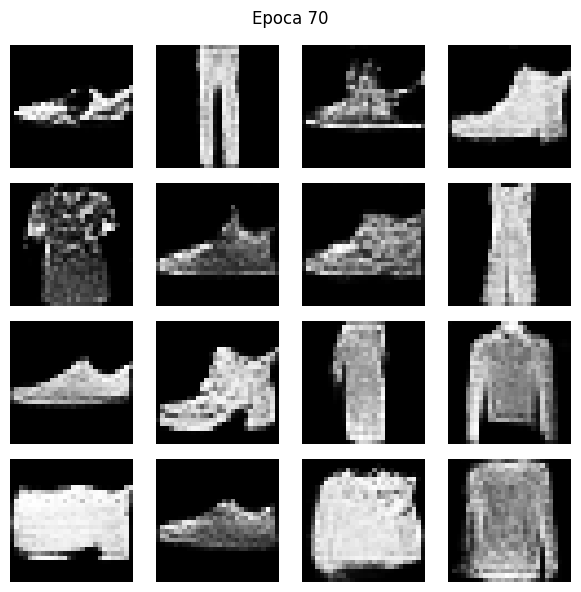

Epoca  71/100 | g_loss=1.0902 | d_loss=1.1350 | 14.3s


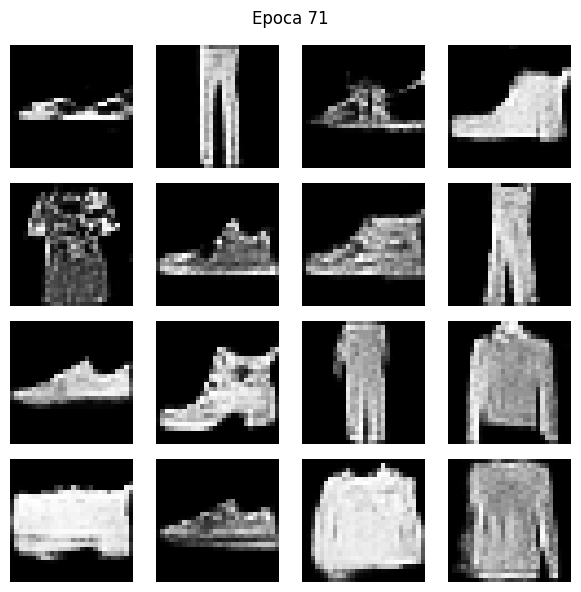

Epoca  72/100 | g_loss=1.0509 | d_loss=1.1591 | 14.3s


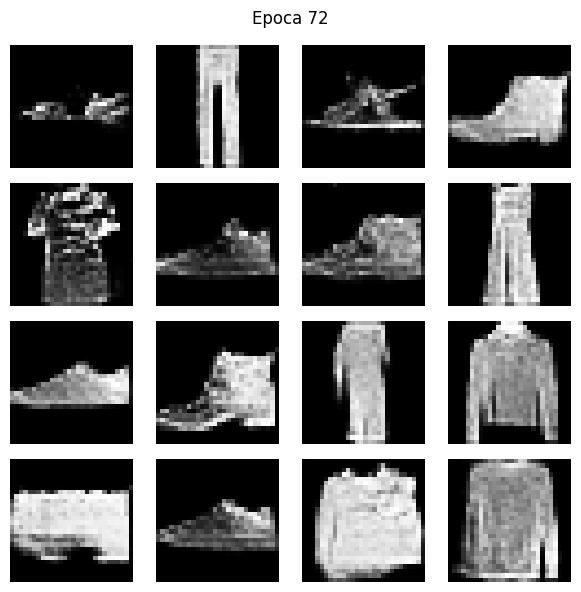

Epoca  73/100 | g_loss=1.0742 | d_loss=1.1330 | 14.3s


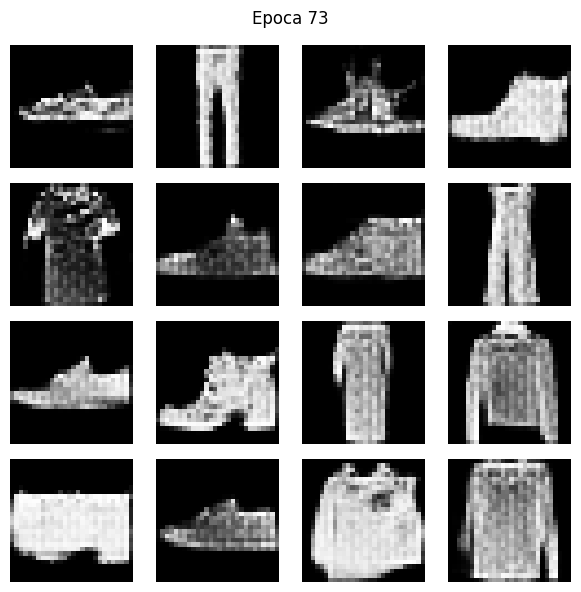

Epoca  74/100 | g_loss=1.1003 | d_loss=1.1286 | 14.3s


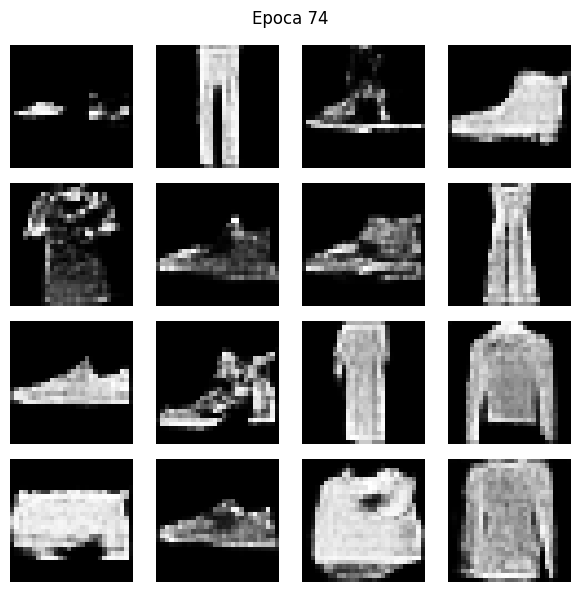

Epoca  75/100 | g_loss=1.1093 | d_loss=1.1322 | 14.3s


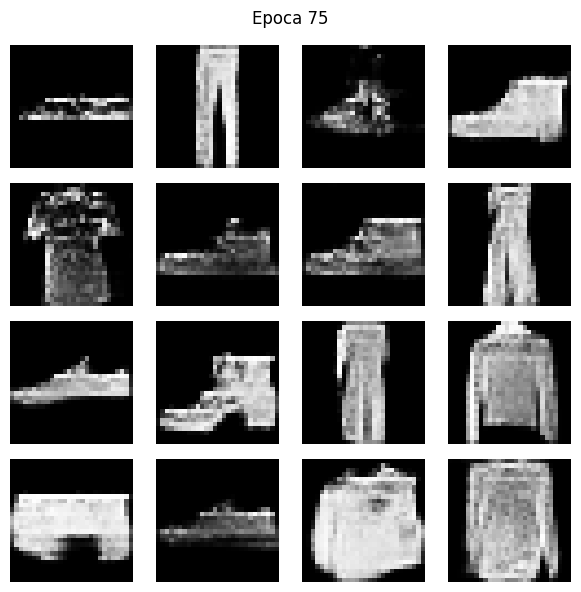

Epoca  76/100 | g_loss=1.0869 | d_loss=1.1539 | 14.3s


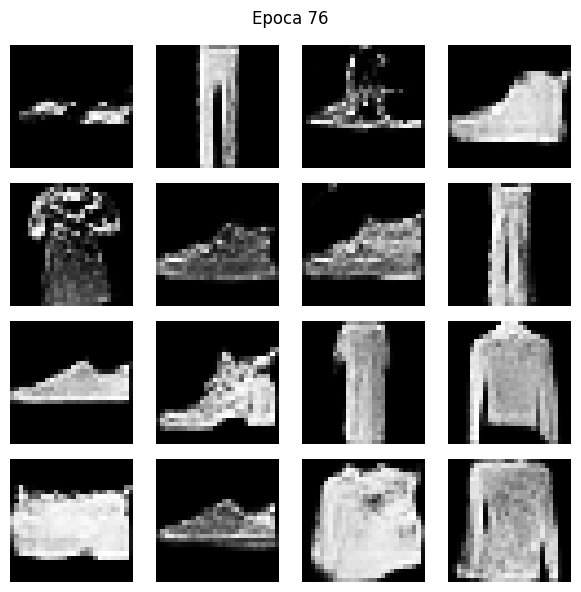

Epoca  77/100 | g_loss=1.0737 | d_loss=1.1481 | 14.3s


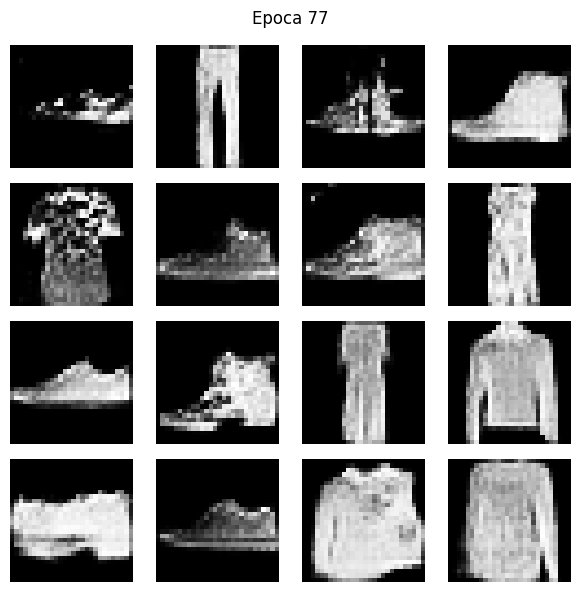

Epoca  78/100 | g_loss=1.0768 | d_loss=1.1552 | 14.3s


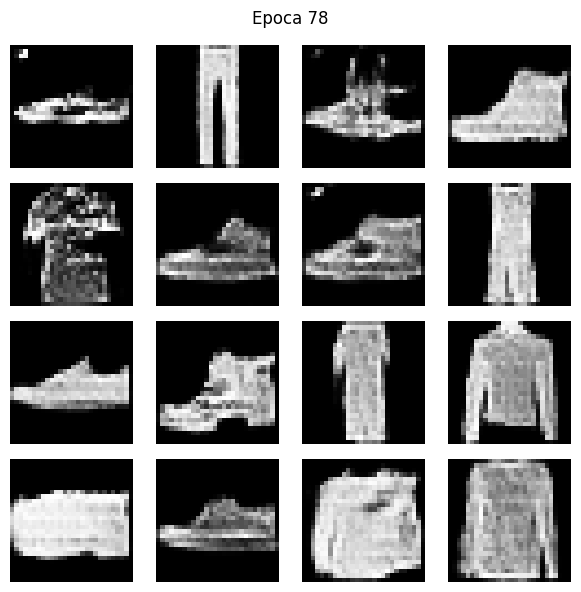

Epoca  79/100 | g_loss=1.0661 | d_loss=1.1551 | 14.3s


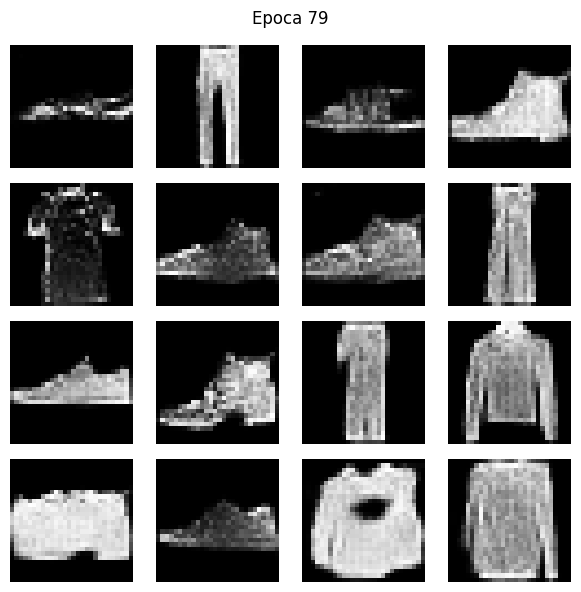

Epoca  80/100 | g_loss=1.0527 | d_loss=1.1678 | 14.3s


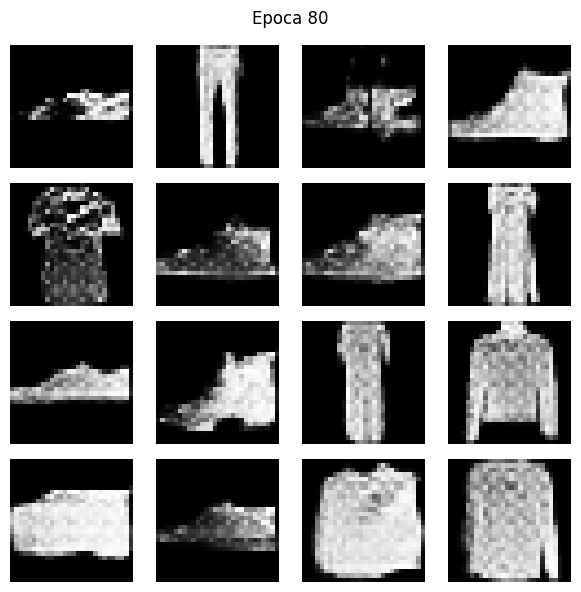

Epoca  81/100 | g_loss=1.0683 | d_loss=1.1548 | 14.3s


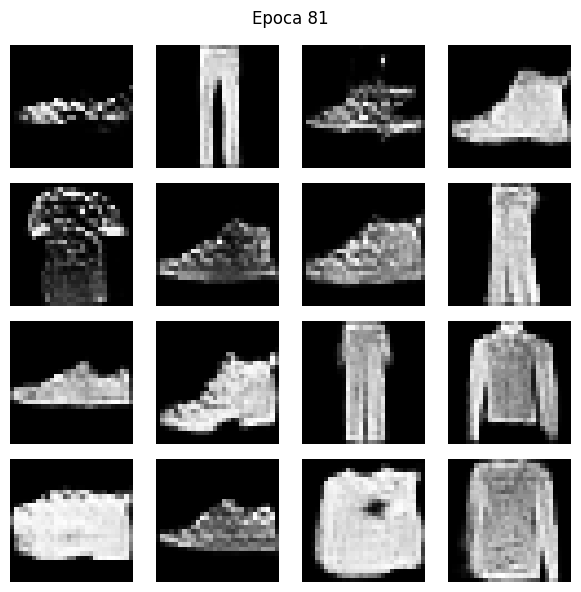

Epoca  82/100 | g_loss=1.0687 | d_loss=1.1366 | 14.3s


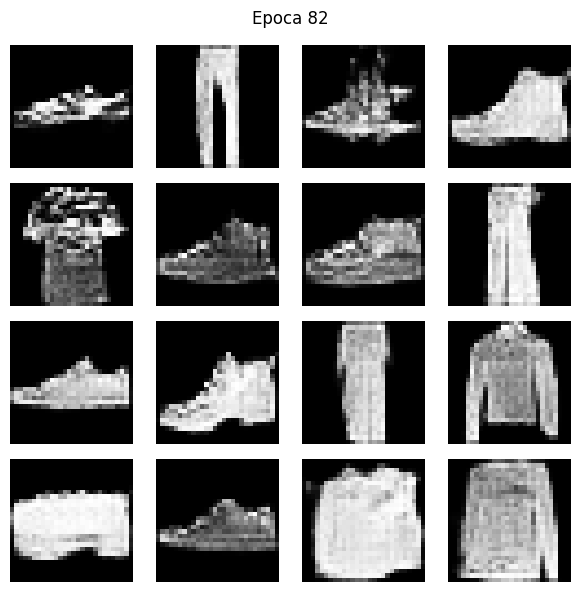

Epoca  83/100 | g_loss=1.0417 | d_loss=1.1831 | 14.3s


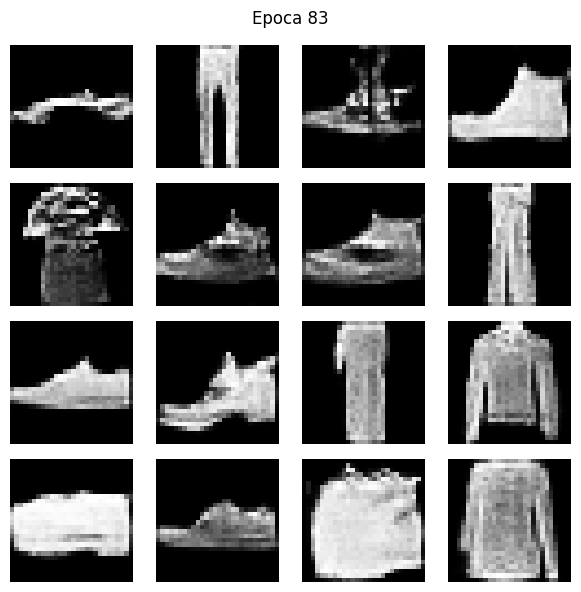

Epoca  84/100 | g_loss=1.0297 | d_loss=1.1765 | 14.3s


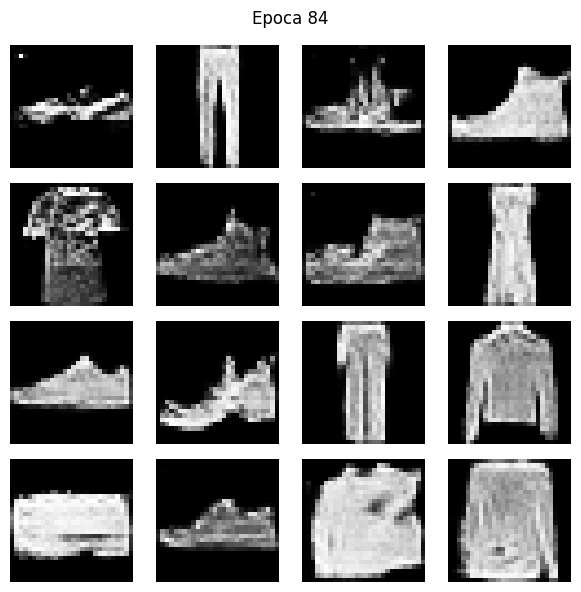

Epoca  85/100 | g_loss=1.0444 | d_loss=1.1749 | 14.3s


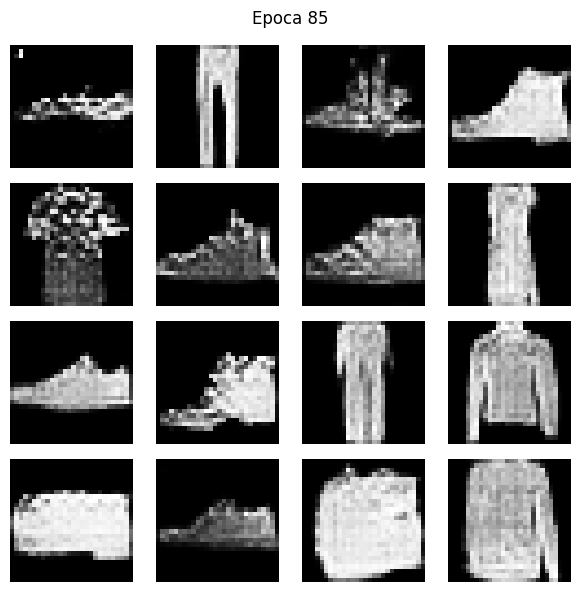

Epoca  86/100 | g_loss=1.0583 | d_loss=1.1505 | 14.3s


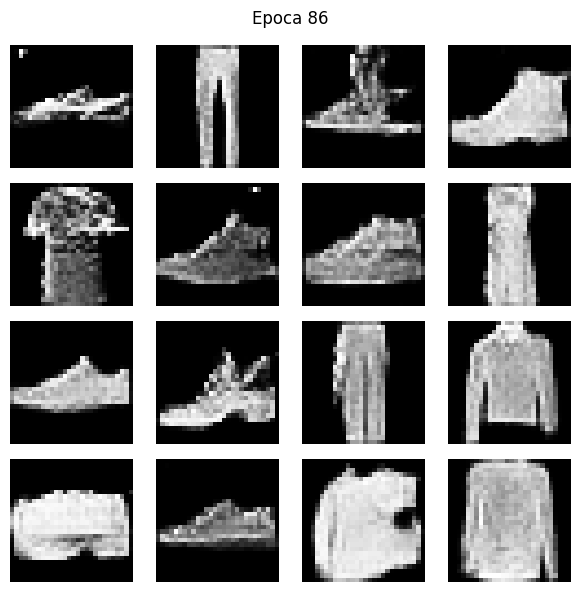

Epoca  87/100 | g_loss=1.0324 | d_loss=1.1839 | 14.3s


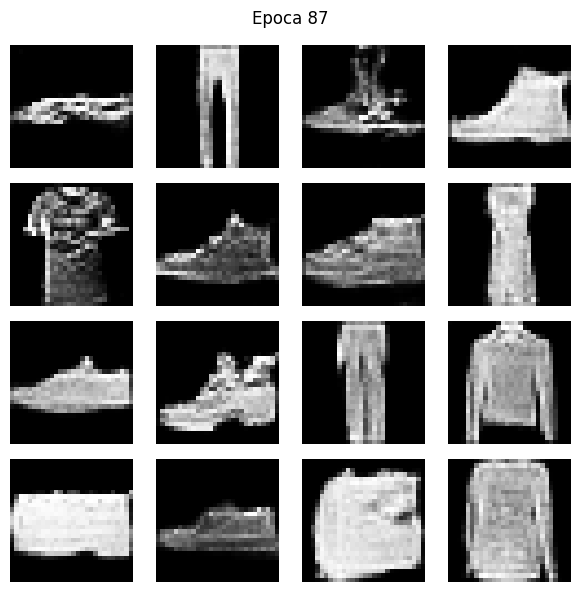

Epoca  88/100 | g_loss=1.0142 | d_loss=1.1992 | 14.3s


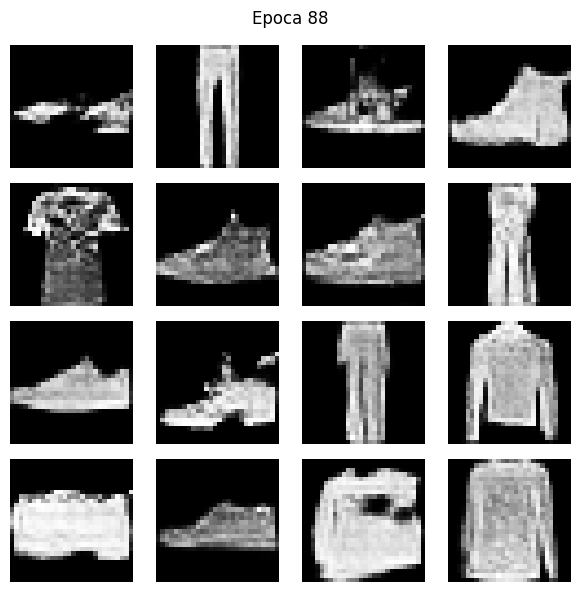

Epoca  89/100 | g_loss=1.0145 | d_loss=1.1948 | 14.3s


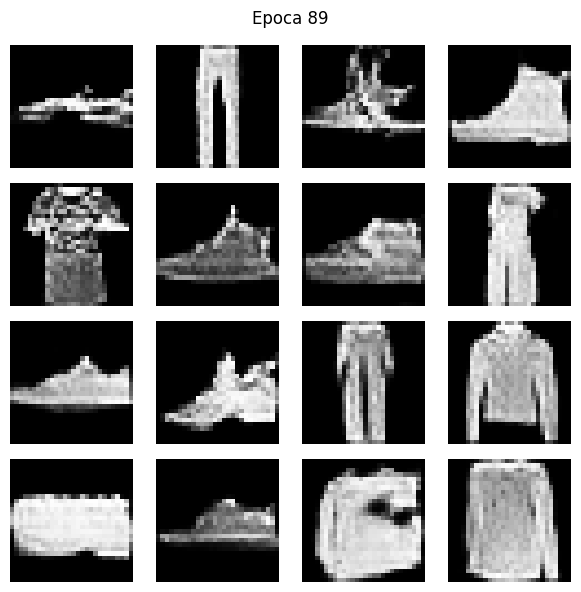

Epoca  90/100 | g_loss=1.0341 | d_loss=1.1818 | 14.3s


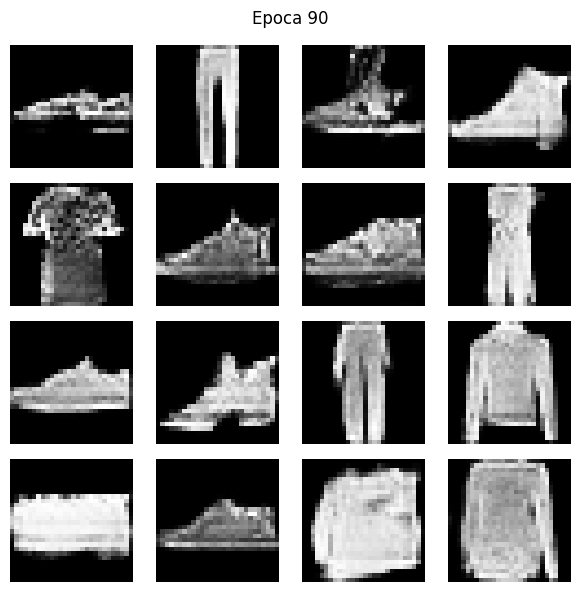

Epoca  91/100 | g_loss=1.0190 | d_loss=1.1814 | 14.3s


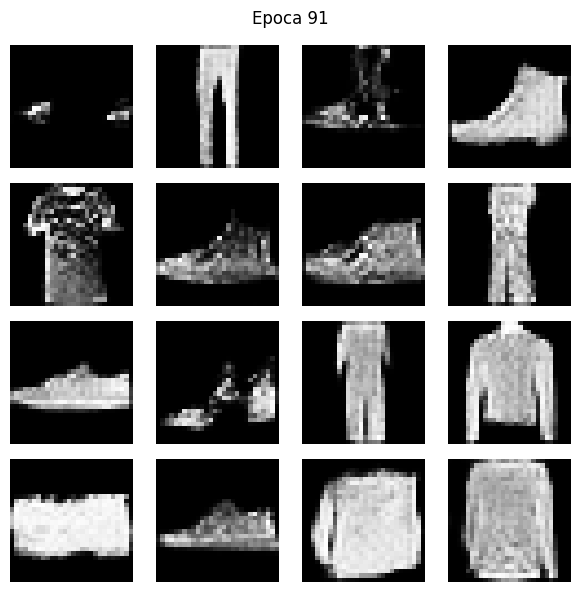

Epoca  92/100 | g_loss=1.0042 | d_loss=1.2035 | 14.3s


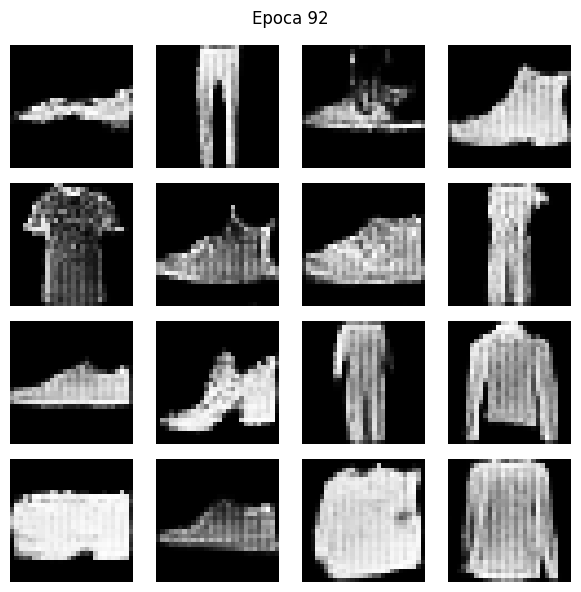

Epoca  93/100 | g_loss=1.0697 | d_loss=1.1381 | 20.5s


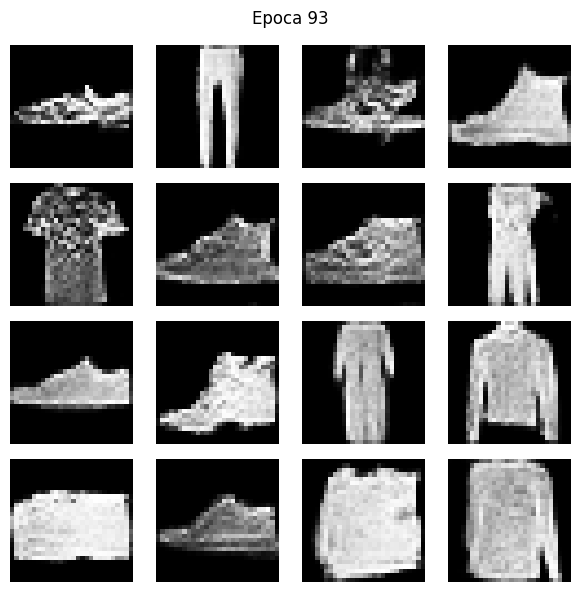

Epoca  94/100 | g_loss=1.0146 | d_loss=1.1983 | 14.4s


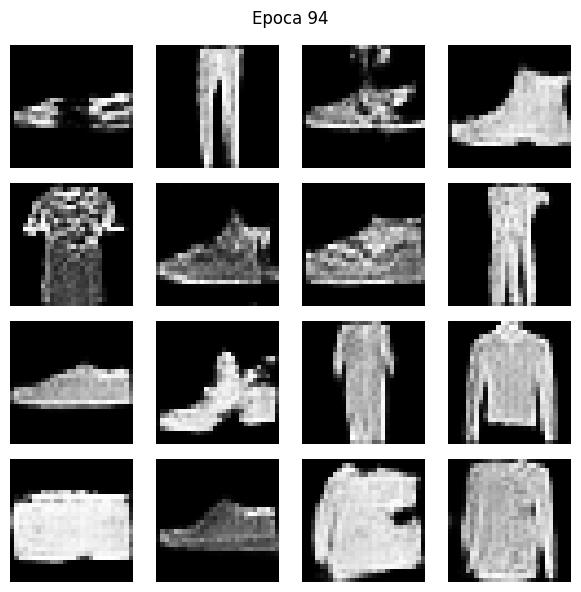

Epoca  95/100 | g_loss=1.0069 | d_loss=1.1998 | 14.3s


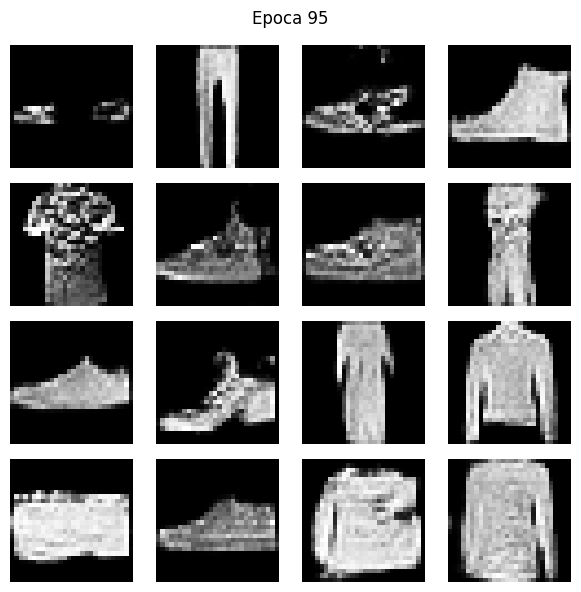

Epoca  96/100 | g_loss=0.9858 | d_loss=1.2167 | 14.3s


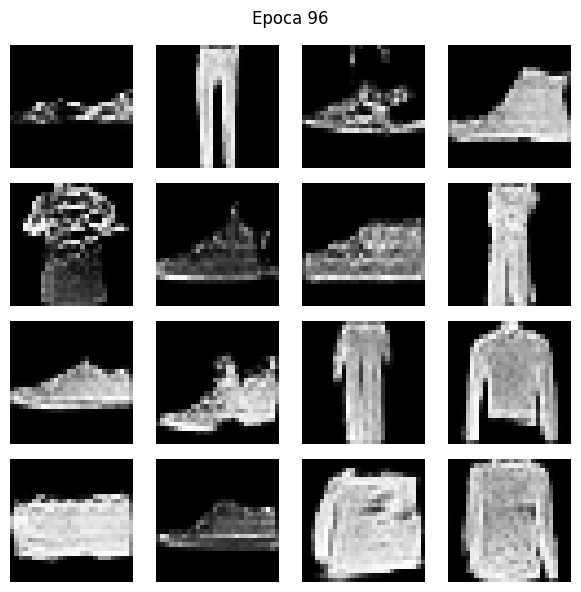

Epoca  97/100 | g_loss=0.9941 | d_loss=1.2035 | 14.3s


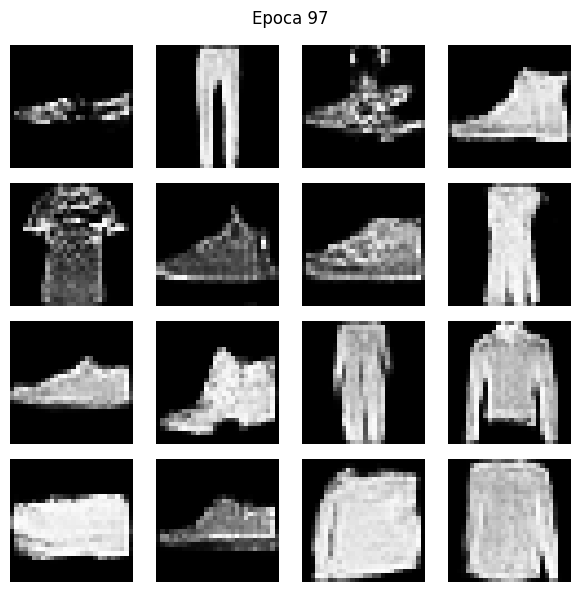

Epoca  98/100 | g_loss=0.9889 | d_loss=1.2157 | 14.3s


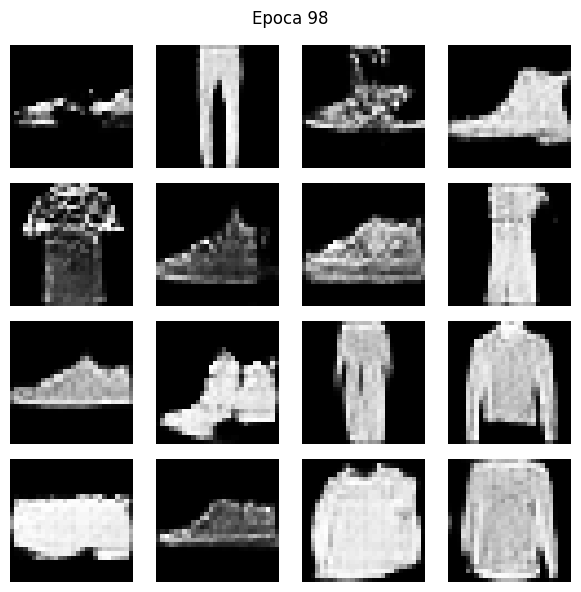

Epoca  99/100 | g_loss=0.9857 | d_loss=1.2098 | 14.3s


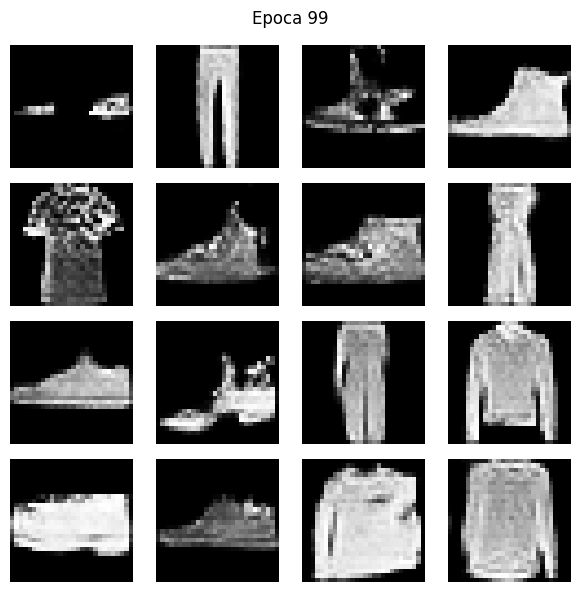

Epoca 100/100 | g_loss=0.9700 | d_loss=1.2165 | 14.3s


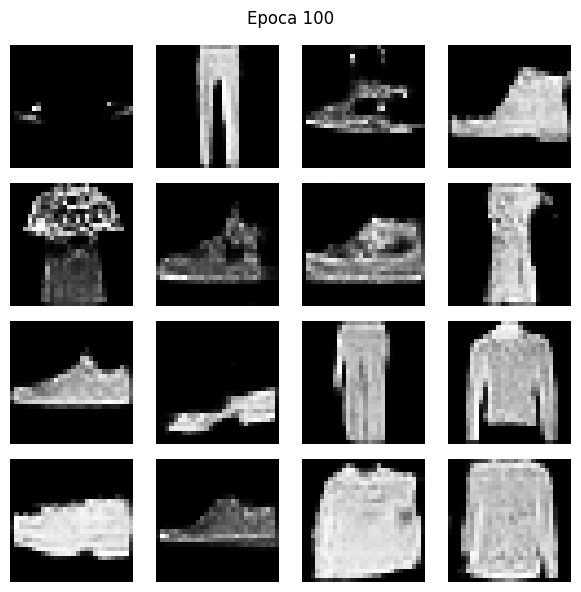

In [ ]:
EPOCHS      = 100        
NUM_PREVIEW = 16       # 4x4 grilă afișată după fiecare epocă

# Zgomot fix folosit la vizualizare -> permite urmărirea evoluției pe aceleași „semințe"
seed = tf.random.normal([NUM_PREVIEW, NOISE_DIM])

@tf.function
def train_step(real_images):
    noise = tf.random.normal([tf.shape(real_images)[0], NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)

        real_logits = discriminator(real_images, training=True)
        fake_logits = discriminator(fake_images, training=True)

        g_loss = generator_loss(fake_logits)
        d_loss = discriminator_loss(real_logits, fake_logits)

    g_grads = gen_tape.gradient(g_loss,  generator.trainable_variables)
    d_grads = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(g_grads,  generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(d_grads, discriminator.trainable_variables))
    return g_loss, d_loss

def show_grid(noise_vec, epoch=None):
    imgs = generator(noise_vec, training=False).numpy()
    plt.figure(figsize=(6, 6))
    for i in range(imgs.shape[0]):
        plt.subplot(4, 4, i + 1)
        # Denormalizăm din [-1, 1] înapoi în [0, 255]
        plt.imshow(imgs[i, :, :, 0] * 127.5 + 127.5, cmap="gray")
        plt.axis("off")
    if epoch is not None:
        plt.suptitle(f"Epoca {epoch}")
    plt.tight_layout()
    plt.show()

history = {"g_loss": [], "d_loss": [], "sec": []}

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    g_losses, d_losses = [], []
    for batch in train_ds:
        g, d = train_step(batch)
        g_losses.append(float(g))
        d_losses.append(float(d))
    sec = time.time() - t0
    history["g_loss"].append(float(np.mean(g_losses)))
    history["d_loss"].append(float(np.mean(d_losses)))
    history["sec"].append(sec)
    print(f"Epoca {epoch:>3}/{EPOCHS} | "
          f"g_loss={history['g_loss'][-1]:.4f} | "
          f"d_loss={history['d_loss'][-1]:.4f} | "
          f"{sec:.1f}s")
    show_grid(seed, epoch=epoch)

## 7. Evaluarea rezultatelor

Grila finală de imagini generate:


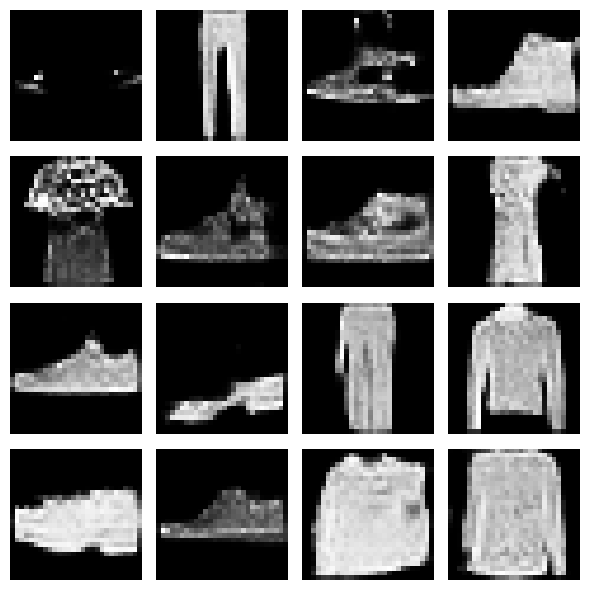

In [11]:
# Grila finală de imagini generate (din același „seed" fix)
print("Grila finală de imagini generate:")
show_grid(seed)

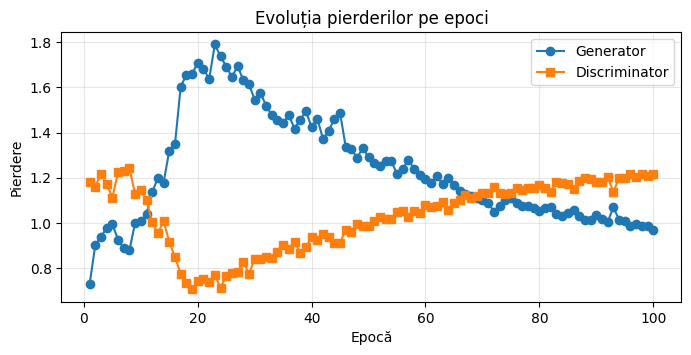

In [12]:
# Evoluția pierderilor pe epoci
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, EPOCHS + 1), history["g_loss"], marker="o", label="Generator")
plt.plot(range(1, EPOCHS + 1), history["d_loss"], marker="s", label="Discriminator")
plt.xlabel("Epocă")
plt.ylabel("Pierdere")
plt.title("Evoluția pierderilor pe epoci")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [13]:
# Sanity-check: scorul discriminatorului pe un batch real vs. unul generat
real_batch = next(iter(train_ds))
fake_batch = generator(tf.random.normal([real_batch.shape[0], NOISE_DIM]),
                       training=False)

real_score = float(tf.reduce_mean(tf.sigmoid(discriminator(real_batch, training=False))))
fake_score = float(tf.reduce_mean(tf.sigmoid(discriminator(fake_batch, training=False))))

print(f"Probabilitate medie ('real') pe imagini reale:    {real_score:.4f}")
print(f"Probabilitate medie ('real') pe imagini generate: {fake_score:.4f}")

Probabilitate medie ('real') pe imagini reale:    0.5691
Probabilitate medie ('real') pe imagini generate: 0.3230


## 8. Concluzii

- Am implementat o rețea **DCGAN** care învață să genereze imagini noi de
  articole vestimentare similare cu cele din setul **Fashion-MNIST**
  (`28×28`, gri), pornind de la vectori de **zgomot aleator** de dimensiune
  `100`. Arhitectura urmărește schema clasică rată de învățare `1e-4` pentru ambele rețele, `Dropout 0.3` în
  discriminator, `tanh` în ultimul strat al generatorului.

- **Cele două rețele se antrenează adversarial**: la fiecare pas,
  discriminatorul încearcă să clasifice corect (real vs. generat), iar
  generatorul încearcă să-l „înșele". Evoluția pierderilor (Secțiunea 7) arată
  tipicul „dans" GAN — pierderea discriminatorului scade rapid la început
  (`d_loss ≈ 1.18 → 0.74` în primele ~20 de epoci), apoi generatorul recuperează
  (`g_loss` urcă spre ~1.77), iar în ultimele 30 de epoci ambele oscilează în
  jurul unui echilibru stabil (`d_loss ≈ 1.10–1.22`, `g_loss ≈ 0.97–1.10`).

- **`Conv2DTranspose` vs `Conv2D`** este distincția cheie de arhitectură:
  - `Conv2DTranspose` (în **generator**) face **upsampling** — pornește de la o
    reprezentare compactă (`7×7`) și o expandează spațial (`14×14`, `28×28`).
    Este cunoscut și ca *fractionally-strided convolution* sau (impropriu)
    *deconvolution*.
  - `Conv2D` (în **discriminator**) face **downsampling** — extrage trăsături
    locale prin filtre convoluționale, reducând rezoluția spațială
    (`28×28 → 7×7`).
  - Ambele folosesc kernel-uri și `strides`, dar în direcții opuse: `Conv2D`
    *reduce* dimensiunea, `Conv2DTranspose` o *mărește*.

- **Rezultate obținute pe rularea completă (100 epoci)**: pierderile finale au
  ajuns la `g_loss = 0.9700` și `d_loss = 1.2165`, iar sanity-check-ul
  discriminatorului dă probabilitatea medie `0.5691` pentru imagini reale și
  `0.3230` pentru imagini generate — adică discriminatorul rămâne nesigur,
  exact regimul dorit pentru un GAN bine antrenat. Antrenarea a fost stabilă
  pe tot parcursul (fără divergențe, fără mode collapse), iar grila finală
  arată **siluete diverse** de articole vestimentare (cămăși, pantaloni,
  încălțăminte, genți)

- **Aplicații practice ale GAN** (selecție): generare de imagini realiste
  (StyleGAN), traducere imagine-la-imagine (CycleGAN, Pix2Pix), super-rezoluție
  (SRGAN), augmentare de date pentru clasificare medicală, generare de fețe
  sintetice, text-to-image (împreună cu modele de tip transformer), detecția de
  conținut generat (forensics), inpainting (umplerea zonelor lipsă din imagini).


## 9. Întrebări de autoevaluare

#### 1. Care sunt pașii de bază pentru crearea unei arhitecturi GAN?

1. **Definirea problemei** și obținerea unui set de date reprezentativ
   (aici: Fashion-MNIST).
2. **Preprocesarea** datelor — redimensionare la forma așteptată, normalizare
   în `[-1, 1]`, construirea unui pipeline `tf.data` (shuffle + batch + prefetch).
3. **Definirea generatorului** ca rețea convoluțională care primește un vector
   de zgomot și produce imagini de forma țintă, folosind `Conv2DTranspose`
   pentru upsampling.
4. **Definirea discriminatorului** ca rețea convoluțională pentru clasificare
   binară (real vs. generat), folosind `Conv2D` + `Dropout`.
5. **Funcțiile de pierdere** — `BinaryCrossentropy(from_logits=True)` pentru
   ambele rețele; etichete `1` pentru real, `0` pentru fals.
6. **Optimizatori separați** (de obicei două instanțe `Adam`).
7. **Bucla de antrenare** — `train_step` într-un `@tf.function`, două
   `GradientTape`-uri, aplicare independentă a gradienților pe ambele rețele.
8. **Vizualizare periodică** a imaginilor generate din **același** zgomot
   (`seed` fix) pentru a urmări progresul.
9. **Evaluare** — calitativă (inspecție vizuală) și cantitativă (FID, IS,
   scorul mediu al discriminatorului).

#### 2. Cum determinăm câte straturi vor fi pentru generator și discriminator?

Numărul de straturi depinde de:

- **Rezoluția țintă**: pentru a ajunge de la `7×7` la `28×28` avem nevoie de
  două straturi `Conv2DTranspose` cu `strides=2` (fiecare dublează dimensiunea
  spațială); simetric, discriminatorul reduce de la `28×28` la `7×7`.
- **Complexitatea datelor**: imagini mai mari și mai detaliate cer mai multe
  straturi și mai multe filtre. Pentru `28×28` sunt suficiente 3–4 straturi
  convoluționale; pentru `64×64` sau `128×128` se adaugă încă un nivel de
  upsampling/downsampling.
- **Simetrie**: de obicei generatorul și discriminatorul au numere apropiate
  de straturi pentru a fi echilibrate în „putere" în jocul adversarial.
- **Resurse disponibile**: număr de parametri vs. timp de antrenare disponibil
  (mai ales pe CPU).

#### 3. Care sunt datele de intrare pentru generator și discriminator?

- **Generator**: un vector de **zgomot aleator** de dimensiune fixă (aici
  `NOISE_DIM = 100`) eșantionat din distribuția normală standard `N(0, 1)`
  (`tf.random.normal`).
- **Discriminator**: o **imagine** de forma `(28, 28, 1)` — fie reală (din
  setul de date, normalizată în `[-1, 1]`), fie generată (ieșirea
  generatorului). Returnează un **logit** (scalar) care, după aplicarea
  `sigmoid`, devine probabilitatea ca imaginea să fie reală.

#### 4. Care e utilitatea Conv2DTranspose și Conv2D?

- **`Conv2DTranspose`** (folosit în **generator**) face **upsampling**:
  pornind de la o reprezentare compactă (ex. `7×7`), crește dimensiunea
  spațială (`14×14`, apoi `28×28`). Este motorul prin care generatorul
  transformă un vector de zgomot într-o imagine cu rezoluție mare.
- **`Conv2D`** (folosit în **discriminator**) face **extragerea de trăsături
  locale** și, când e combinat cu `strides=2`, **downsampling**. Reduce
  rezoluția spațială și creează ierarhii de trăsături (margini → texturi →
  forme), permițând clasificarea binară.

Pe scurt: ambele folosesc filtre convoluționale și `strides`, dar `Conv2D`
*reduce* dimensiunea spațială, iar `Conv2DTranspose` o *mărește*.

#### 5. Cum se calculează funcția loss pentru generator și discriminator?

Folosim `BinaryCrossentropy(from_logits=True)`:

```
discriminator_loss = BCE(1, D(real)) + BCE(0, D(fake))
generator_loss     = BCE(1, D(fake))
```

- Discriminatorul vrea ca `D(real) → 1` și `D(fake) → 0`.
- Generatorul vrea exact opusul: ca discriminatorul să clasifice imaginile
  generate ca **reale** (`D(fake) → 1`); de aceea ținta din pierderea
  generatorului este `1`.

#### 6. Cum are loc antrenarea rețelei GAN?

Pe scurt: două rețele se antrenează **simultan, în opoziție**. La fiecare batch:

1. Se eșantionează zgomot și se generează imagini false cu
   `generator(noise, training=True)`.
2. Discriminatorul scoate logiti pe imaginile reale și pe cele false.
3. Se calculează `g_loss` și `d_loss`.
4. Două `GradientTape`-uri separate calculează gradienții pentru generator și
   pentru discriminator.
5. Se aplică `apply_gradients` independent pe variabilele fiecărei rețele.

Antrenarea continuă mai multe epoci, iar generatorul se îmbunătățește treptat
până când discriminatorul nu mai poate distinge fiabil între real și generat.

#### 7. Cum e posibilă îmbunătățirea rezultatelor generatorului?

- **Mai multe epoci** (efectul cel mai vizibil în Fashion-MNIST).
- **Optimizator Adam** cu `learning_rate` ajustat (de obicei `1e-4` cu
  `beta_1=0.5` ca în DCGAN original) și echilibrat între generator și
  discriminator.
- **Arhitectură mai adâncă** (mai multe straturi `Conv2DTranspose`, mai multe
  filtre, sau o variantă progresivă).
- **Stabilizatori**: `BatchNormalization` în generator, `LeakyReLU` în loc de
  ReLU (evită „dead neurons"), `Dropout` în discriminator.
- **Variante ale loss-ului**: WGAN / WGAN-GP (Wasserstein loss + gradient
  penalty), LSGAN, hinge loss — reduc instabilitatea.
- **Label smoothing** (ex. țintă `0.9` în loc de `1.0` pentru „real"), pentru
  a împiedica discriminatorul să devină prea încrezător.
- **Mai multe date** sau **augmentare** (rotații, flip-uri).

#### 8. Ce funcții de activare folosim în straturile interne, dar în stratul de ieșire?

- **În straturile interne**:
  - **Generator**: `LeakyReLU` (cu `negative_slope ≈ 0.2`) — permite gradient
    nenul pentru valori negative, ceea ce reduce riscul de „mode collapse" și
    de gradient mort.
  - **Discriminator**: tot `LeakyReLU`.
- **În stratul de ieșire**:
  - **Generator**: `tanh` — produce valori în `[-1, 1]`, exact intervalul în
    care am normalizat datele reale.
  - **Discriminator**: niciuna (logit). Sigmoidul este aplicat implicit de
    `BinaryCrossentropy(from_logits=True)` (mai stabil numeric). Alternativ se
    poate aplica `sigmoid` explicit cu `from_logits=False`.

#### 9. Dați exemple de arhitecturi GAN, care sunt avantajele fiecărui tip?

- **Vanilla GAN** (Goodfellow, 2014) — arhitectură MLP simplă; util didactic.
- **DCGAN** (Radford et al., 2015) — rețele convoluționale,
  `Conv2DTranspose` în generator, `Conv2D` în discriminator; *standardul*
  pentru imagini și baza acestei lucrări.
- **cGAN** (Conditional GAN) — primesc o etichetă suplimentară; permit
  **controlul** clasei generate (ex. „generează un pulover", nu o imagine la
  întâmplare).
- **WGAN / WGAN-GP** — folosesc Wasserstein loss + gradient penalty;
  antrenare mult mai **stabilă**, fără mode collapse.
- **Pix2Pix** — traducere imagine-la-imagine cu perechi (schiță → fotografie).
- **CycleGAN** — traducere imagine-la-imagine **fără perechi**
  (cai ↔ zebre, vară ↔ iarnă).
- **StyleGAN / StyleGAN2 / StyleGAN3** — fețe foto-realiste de înaltă
  rezoluție; **control fin** asupra stilului prin „style mixing".
- **BigGAN** — rezoluție mare + condiționare pe clase, antrenat la scară mare.
- **SRGAN / ESRGAN** — super-rezoluție: îmbunătățește rezoluția imaginilor.

#### 10. Dați exemple de aplicare a modelului GAN.

- Generare de imagini realiste de fețe, animale, peisaje
  (StyleGAN, BigGAN).
- Augmentare de date pentru sarcini de clasificare (utilă în domenii cu date
  puține — ex. imagistică medicală).
- Super-rezoluție: îmbunătățirea rezoluției fotografiilor și video-urilor
  (SRGAN, ESRGAN).
- Traducere imagine-la-imagine: zi → noapte, vară → iarnă, schiță → fotografie
  (CycleGAN, Pix2Pix).
- **Inpainting** — completarea zonelor lipsă dintr-o imagine.
- Generare **text-to-image** (de obicei combinate cu modele de tip
  transformer / difuzie).
- Editare semantică de imagini și manipulare a atributelor (vârstă, expresie
  facială, culoare păr).
- Generare de date sintetice tabelare (CTGAN) pentru anonimizare.
- **Detectarea** conținutului generat (forensics) — clasificator binar
  real/fals.
- Animație și artă generativă (avatars, jocuri, design).
